#Predicción de las muertes por CoVid-19

## Carga y visualización de datos

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. CONFIGURACIÓN Y FUNCIONES AUXILIARES
# ==========================================

base_path = '/content/drive/MyDrive/Colab Notebooks/AARN/PROYECTO-AARN/'

files = {
    'muertes': 'covid19-deceasedPeopleCount.json',
    'hospital': 'covid19-byhospital.json',
    'estado': 'covid19-epidemic-status.json',
    'pcr_demograf': 'covid19-pcr-positives.json',
    'zonas_salud': 'covid19-byhealthzone.json'
    # 'pcr_global' no es estrictamente necesario si tenemos el demográfico y estado
}

def cargar_json(nombre_archivo):
    """Carga JSON intentando UTF-8 y luego Latin-1 si falla."""
    path = base_path + nombre_archivo
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except UnicodeDecodeError:
        print(f"{nombre_archivo}: UTF-8 ha fallado. Prueba con Latin-1.")
        with open(path, 'r', encoding='latin-1') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"No encontrado: {nombre_archivo}")
        return None

def procesar_fecha_segura(df, col_fecha='date'):
    """
    Convierte fechas a datetime.
    - Errors='coerce' convierte fechas corruptas (ej: año 0006) en NaT.
    - Elimina las filas con NaT.
    - Elimina la zona horaria (tz_localize(None)).
    """
    if df is None or df.empty: return df

    # 1. Convertir a datetime (lo corrupto se vuelve NaT)
    df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')

    # 2. Contar y borrar errores
    n_antes = len(df)
    df = df.dropna(subset=[col_fecha])
    n_despues = len(df)

    if n_antes != n_despues:
        print(f"     -> Se han eliminado {n_antes - n_despues} filas con fechas corruptas.")

    # 3. Quitar timezone para poder hacer merge
    df[col_fecha] = df[col_fecha].dt.tz_localize(None)
    return df

# ==========================================
# 2. CARGA Y PROCESAMIENTO DE DATOS
# ==========================================
print("--- 1. Carga y Procesado de Archivos ---")
raw_data = {}
for key, fname in files.items():
    data = cargar_json(fname)
    if data: raw_data[key] = data

dfs_to_merge = []

# --- A. TARGET: MUERTES (Base del sistema) ---
if 'muertes' in raw_data:
    df_master = pd.DataFrame(raw_data['muertes']['byDate'])
    df_master = df_master.rename(columns={'deceasedCount': 'target_muertes'})
    df_master = procesar_fecha_segura(df_master)
    print("Muertes procesado.")
else:
    raise ValueError("Falta el archivo de muertes. No podemos predecir nada.")

# --- B. HOSPITAL (Datos complejos) ---
if 'hospital' in raw_data:
    try:
        df_hospi = pd.json_normalize(raw_data['hospital']['byDate'])
        # Seleccionar columnas numéricas 'totals.'
        cols_hospi = [c for c in df_hospi.columns if c.startswith('totals.')]
        df_hospi = df_hospi[['date'] + cols_hospi]
        # Renombrar para quitar el prefijo 'totals.'
        df_hospi.columns = [c.replace('totals.', 'hosp_') if 'totals.' in c else c for c in df_hospi.columns]

        df_hospi = procesar_fecha_segura(df_hospi)
        dfs_to_merge.append(df_hospi)
        print("Hospital procesado.")
    except Exception as e: print(f"Error Hospital: {e}")

# --- C. ESTADO EPIDÉMICO (R0, PCRs) ---
if 'estado' in raw_data:
    try:
        df_estado = pd.DataFrame(raw_data['estado']['byDate'])
        # Selección de columnas clave
        cols_interes = [
            'date', 'r0', 'pcrPositiveCount', 'pcrTestCount',
            'newHospitalAdmissionsWithPCRCount', 'icuPeopleCount'
        ]
        # Solo las que existan realmente
        cols_validas = [c for c in cols_interes if c in df_estado.columns]
        df_estado = df_estado[cols_validas]
        # Prefijo para identificar
        df_estado.columns = ['est_' + c if c != 'date' else 'date' for c in df_estado.columns]

        df_estado = procesar_fecha_segura(df_estado)
        dfs_to_merge.append(df_estado)
        print("Estado Epidémico procesado.")
    except Exception as e: print(f"Error Estado: {e}")

# --- D. PCR DEMOGRÁFICO ---
if 'pcr_demograf' in raw_data:
    try:
        df_demog = pd.DataFrame(raw_data['pcr_demograf']['byDate'])
        # Prefijo
        df_demog.columns = ['demo_' + c if c != 'date' else 'date' for c in df_demog.columns]

        df_demog = procesar_fecha_segura(df_demog)
        dfs_to_merge.append(df_demog)
        print("Demografía procesada.")
    except Exception as e: print(f"Error Demografía: {e}")

# --- E. ZONAS DE SALUD (Agregación) ---
if 'zonas_salud' in raw_data:
    try:
        data_zonas = []
        for entry in raw_data['zonas_salud']['newPositivesByDateByHealthZone']:
            fecha_raw = entry['date']
            total_dia = sum(item.get('newPositiveCount', 0) for item in entry['items'])
            data_zonas.append({'date': fecha_raw, 'zonas_nuevos_positivos': total_dia})

        df_zonas = pd.DataFrame(data_zonas)
        df_zonas = procesar_fecha_segura(df_zonas) # Aquí filtrará el año 0006

        dfs_to_merge.append(df_zonas)
        print("Zonas de Salud procesadas.")
    except Exception as e: print(f"Error Zonas Salud: {e}")


# ==========================================
# 3. FUSIÓN Y LIMPIEZA (IMPUTACIÓN)
# ==========================================
print("\n--- 2. Fusionar Datos ---")

for df in dfs_to_merge:
    # Outer join para no perder días si un archivo tiene un hueco
    df_master = pd.merge(df_master, df, on='date', how='outer')

# Ordenar por fecha es CRÍTICO para el ffill
df_master = df_master.sort_values('date')

# --- ESTRATEGIA DE RELLENO (IMPUTACIÓN) ---
print("--- 3. Aplicar Imputación Inteligente ---")

# 1. Variables de ESTADO (Continuas): Usamos el valor del día anterior
# Si no hay dato de ocupación hospitalaria o R0 hoy, asumimos que es igual a ayer.
cols_estado_continuo = [c for c in df_master.columns if 'r0' in c or 'PeopleCount' in c]
print(f"   -> Aplicando FFILL a {len(cols_estado_continuo)} variables de estado (ej: R0, UCIs)")
df_master[cols_estado_continuo] = df_master[cols_estado_continuo].ffill()

# 2. Variables de CONTEO (Discretas): Rellenamos con 0
# Si no hay dato de nuevos positivos, asumimos 0 (o que no hubo reporte)
df_master = df_master.fillna(0)

# 3. Feature Engineering: VACUNA
fecha_vacuna = pd.to_datetime('2020-12-27')
df_master['feature_hay_vacuna'] = (df_master['date'] >= fecha_vacuna).astype(int)

# Eliminar columna fecha para el entrenamiento
cols_excluir = ['date']
features_cols = [c for c in df_master.columns if c not in cols_excluir]

print(f"\nDimensiones finales del dataset: {df_master.shape}")
print(f"Total features: {len(features_cols)}")

--- 1. Carga y Procesado de Archivos ---
covid19-byhospital.json: UTF-8 ha fallado. Prueba con Latin-1.
covid19-pcr-positives.json: UTF-8 ha fallado. Prueba con Latin-1.
covid19-byhealthzone.json: UTF-8 ha fallado. Prueba con Latin-1.
Muertes procesado.
Hospital procesado.
Estado Epidémico procesado.
Demografía procesada.
     -> Se han eliminado 91 filas con fechas corruptas.
Zonas de Salud procesadas.

--- 2. Fusionar Datos ---
--- 3. Aplicar Imputación Inteligente ---
   -> Aplicando FFILL a 11 variables de estado (ej: R0, UCIs)

Dimensiones finales del dataset: (2438, 36)
Total features: 35


/tmp/ipython-input-3217439114.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_fecha] = df[col_fecha].dt.tz_localize(None)


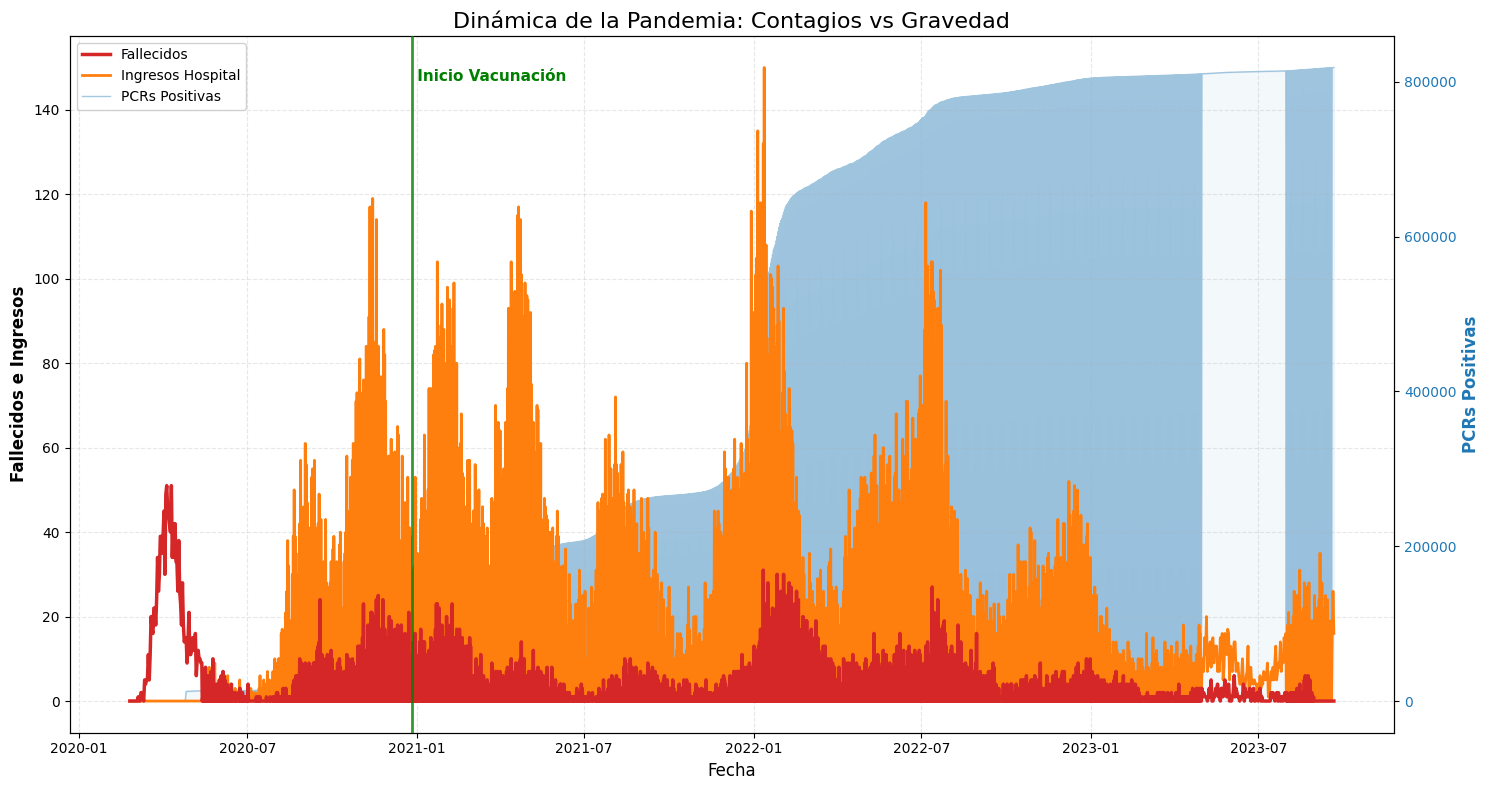

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 4. VISUALIZACIÓN DE LOS DATOS
# ==========================================

fig, ax1 = plt.subplots(figsize=(15, 8))

# --- PASO 1: CREAR EL EJE TRASERO PRIMERO (PCRs) ---
# Creamos el eje gemelo para las PCRs
ax2 = ax1.twinx()
color_pcr = '#1f77b4' # Azul
ax2.set_ylabel('PCRs Positivas', color=color_pcr, fontsize=12, fontweight='bold')

# Pintamos las PCRs
if 'est_pcrPositiveCount' in df_master.columns:
    l3, = ax2.plot(df_master['date'], df_master['est_pcrPositiveCount'],
                   color=color_pcr,
                   linewidth=1,
                   linestyle='-',
                   alpha=0.4,  # Un poco transparente para no molestar
                   label='PCRs Positivas')

    # Opcional: Añadir un relleno muy suave para dar contexto de volumen
    ax2.fill_between(df_master['date'], df_master['est_pcrPositiveCount'],
                     color=color_pcr, alpha=0.05)

    ax2.tick_params(axis='y', labelcolor=color_pcr)

# --- PASO 2: EJE DELANTERO (Muertes y Hospital) ---
# Pintamos en ax1
color_muertes = '#d62728' # Rojo
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Fallecidos e Ingresos', color='black', fontsize=12, fontweight='bold')

# Fallecidos (Bien visible)
l1, = ax1.plot(df_master['date'], df_master['target_muertes'],
               color=color_muertes, linewidth=2.5, zorder=10, label='Fallecidos')

# Hospitalizaciones
if 'est_newHospitalAdmissionsWithPCRCount' in df_master.columns:
    color_hosp = '#ff7f0e' # Naranja
    l2, = ax1.plot(df_master['date'], df_master['est_newHospitalAdmissionsWithPCRCount'],
                   color=color_hosp, linewidth=2, zorder=9, label='Ingresos Hospital')
else:
    l2 = None

ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, which='both', linestyle='--', alpha=0.3)

# --- PASO 3: EL TRUCO DE MAGIA (Z-ORDER) ---
# Aquí es donde arreglamos que las PCRs tapen lo demás
ax1.set_zorder(ax2.get_zorder() + 1) # Ponemos el eje 1 (rojo/naranja) ENCIMA del eje 2
ax1.patch.set_visible(False)         # Hacemos el fondo del eje 1 TRANSPARENTE (si no, lo tapa todo)

# --- EVENTO VACUNA ---
fecha_vacuna = pd.to_datetime('2020-12-27')
ax1.axvline(x=fecha_vacuna, color='green', linestyle='-', linewidth=2, alpha=0.8, zorder=11)
ax1.text(fecha_vacuna, ax1.get_ylim()[1]*0.95, ' Inicio Vacunación',
         color='green', fontweight='bold', ha='left', va='top', fontsize=11, zorder=11)

# --- LEYENDA ---
lines = [l1] + ([l2] if l2 else []) + ([l3] if 'l3' in locals() else [])
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10, frameon=True, fancybox=True, framealpha=0.9)

plt.title('Dinámica de la Pandemia: Contagios vs Gravedad', fontsize=16)
fig.tight_layout()
plt.show()

## Creación de modelos

###Modelo MLP

In [12]:
class COVIDMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64], output_dim=1, dropout=0.2):
        super(COVIDMLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # Aplanar secuencia: (batch, window, features) -> (batch, window*features)
        x = x.view(x.size(0), -1)
        return self.model(x).squeeze()

###Modelo LSTM

In [13]:
class COVIDLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super(COVIDLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Inicializar hidden state y cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Tomamos el último paso temporal
        out = out[:, -1, :]

        # Predicción
        prediction = self.fc(out)
        return prediction.squeeze()

###Modelo LSTM + atención

In [14]:
class COVIDLSTMWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super(COVIDLSTMWithAttention, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        #LSTM de siempre
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)

        # --- NOVEDAD: CAPA DE ATENCIÓN ---
        # Calculamos un "peso" para cada paso de tiempo
        self.attention = nn.Linear(hidden_dim, 1)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, features) -> (32, 7, 35)

        # 1. Pasada LSTM
        # lstm_out shape: (batch, seq_len, hidden_dim) -> Contiene la "memoria" de CADA día
        lstm_out, _ = self.lstm(x)

        # 2. Mecanismo de Atención
        # Queremos saber qué día es importante.
        # attn_weights = softmax(capa_lineal(lstm_out))
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1) # (batch, seq_len, 1)

        # 3. Context Vector (Suma ponderada)
        # Multiplicamos cada día por su importancia y sumamos
        # context = sum(lstm_out * weights)
        context = torch.sum(attn_weights * lstm_out, dim=1) # (batch, hidden_dim)

        # 4. Predicción final usando el contexto enriquecido
        prediction = self.fc(context)

        return prediction.squeeze()

### Modelo GRU

In [15]:
import torch
import torch.nn as nn

class COVIDGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.2):
        super(COVIDGRU, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # DEFINICIÓN DE LA CAPA GRU
        # A diferencia de LSTM, no gestiona 'cell state', solo 'hidden state'.
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Capa totalmente conectada para la predicción final
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)

        # Inicializamos el estado oculto h0 con ceros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # PROPAGACIÓN (Forward)
        # La GRU devuelve:
        # out: contiene los estados ocultos de TODOS los pasos de tiempo
        # hn: el estado oculto del ÚLTIMO paso (de todas las capas)
        out, hn = self.gru(x, h0)

        # Tomamos la salida del último paso de tiempo (t = 7) para predecir
        # out[:, -1, :] -> [Batch, Último instante, Features ocultas]
        last_time_step = out[:, -1, :]

        # Predicción final
        prediction = self.fc(last_time_step)

        return prediction.squeeze() # Quitamos dimensiones extra para que quede [Batch]

##Opción 1: datos ordenados cronológicamente

### Preprocesado de datos (normalización y ventanas)

In [16]:
# ==========================================
# 4. PREPARACIÓN PARA PYTORCH (Scaler solo con train)
# ==========================================

# --- 1. División cronológica para definir train/val/test ---
prop_train = 0.70
prop_val   = 0.15
n_samples  = len(df_master)
train_idx  = int(n_samples * prop_train)
val_idx    = int(n_samples * (prop_train + prop_val))

# --- 2. Escalado (MinMax) solo usando train ---
scaler = MinMaxScaler()
scaler.fit(df_master[features_cols][:train_idx])  # Ajuste solo con train
data_scaled = scaler.transform(df_master[features_cols])  # Transformamos todo

# --- 3. Crear secuencias (ventana deslizante) ---
WINDOW_SIZE = 7
target_col_idx = features_cols.index('target_muertes')

X_list, y_list = [], []
for i in range(len(data_scaled) - WINDOW_SIZE):
    X_list.append(data_scaled[i : i + WINDOW_SIZE])                # Ventana de 7 días
    y_list.append(data_scaled[i + WINDOW_SIZE, target_col_idx])   # Muertes día siguiente

X = np.array(X_list)
y = np.array(y_list)

# --- 4. Tensores ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.from_numpy(X).float().to(device)
y_tensor = torch.from_numpy(y).float().to(device)

# --- 5. División cronológica en train/val/test usando los índices calculados ---
train_dataset = TensorDataset(X_tensor[:train_idx], y_tensor[:train_idx])
val_dataset   = TensorDataset(X_tensor[train_idx:val_idx], y_tensor[train_idx:val_idx])
test_dataset  = TensorDataset(X_tensor[val_idx:], y_tensor[val_idx:])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\n--- Datos Listos para Entrenamiento ---")
print(f"X Train shape: {X_tensor[:train_idx].shape}")
print(f"X Val shape:   {X_tensor[train_idx:val_idx].shape}")
print(f"X Test shape:  {X_tensor[val_idx:].shape}")
print(f"Dispositivo: {device}")



--- Datos Listos para Entrenamiento ---
X Train shape: torch.Size([1706, 7, 35])
X Val shape:   torch.Size([366, 7, 35])
X Test shape:  torch.Size([359, 7, 35])
Dispositivo: cpu


###Baseline: las muertes de un día son iguales a las muertes del día anterior

--- RESULTADOS BASELINE (MODELO DE PERSISTENCIA) ---
 SCALED RMSE: 0.0373 (Adimensional)
------------------------------
 SCALED MAE:  0.0270 (Adimensional)
------------------------------


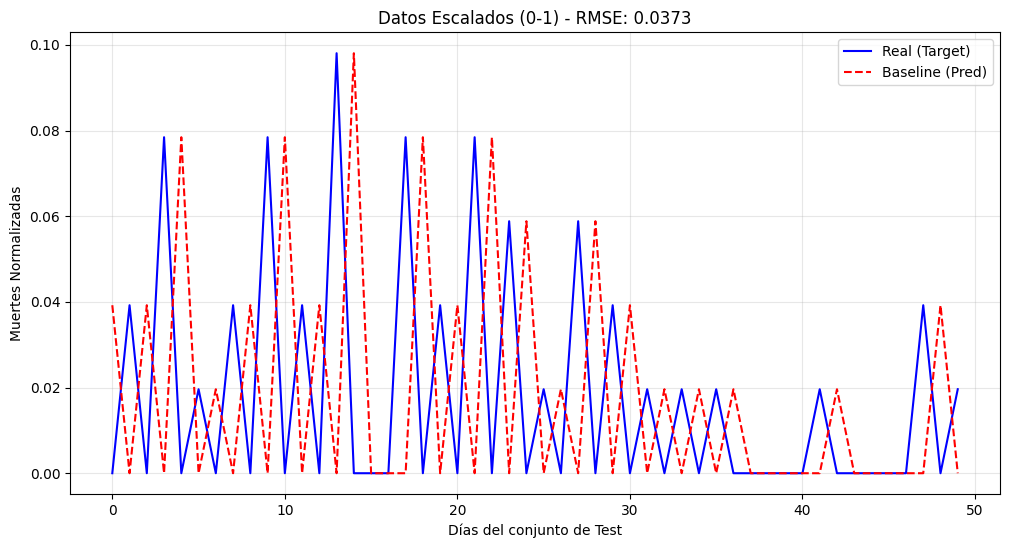

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# --- 0. RECUPERAR DATOS DE TEST ---
X_test = X[val_idx:]
y_test = y[val_idx:]

# --- 1. GENERAR PREDICCIONES DEL BASELINE ---
# La predicción es el valor del último día de la ventana (index -1)
y_pred_baseline = X_test[:, -1, target_col_idx]

# ==========================================
# 2. DES-ESCALADO (VOLVER A MUNDO REAL)
# ==========================================

# Necesitamos saber cuántas features tenía el scaler original
n_features = X_test.shape[2]

# Creamos matrices "dummy" (vacías) con la forma correcta para engañar al scaler
dummy_pred = np.zeros((len(y_pred_baseline), n_features))
dummy_true = np.zeros((len(y_test), n_features))

# Rellenamos SOLO la columna de las muertes (target_col_idx)
dummy_pred[:, target_col_idx] = y_pred_baseline
dummy_true[:, target_col_idx] = y_test

# Aplicamos la inversa
# Y extraemos solo la columna que nos interesa
y_pred_real = scaler.inverse_transform(dummy_pred)[:, target_col_idx]
y_true_real = scaler.inverse_transform(dummy_true)[:, target_col_idx]

# ==========================================
# 3. CÁLCULO DE ERRORES
# ==========================================

# A. Error Escalado (0-1)
mse_scaled = mean_squared_error(y_test, y_pred_baseline)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_baseline)

# # B. Error Real (Personas)
# mse_real = mean_squared_error(y_true_real, y_pred_real)
# rmse_real = np.sqrt(mse_real)
# mae_real = mean_absolute_error(y_true_real, y_pred_real)

print("--- RESULTADOS BASELINE (MODELO DE PERSISTENCIA) ---")
print(f" SCALED RMSE: {rmse_scaled:.4f} (Adimensional)")
#print(f" REAL   RMSE: {rmse_real:.2f} muertes")
print("-" * 30)
print(f" SCALED MAE:  {mae_scaled:.4f} (Adimensional)")
#print(f" REAL   MAE:  {mae_real:.2f} muertes de error promedio diario")
print("-" * 30)

# ==========================================
# 4. VISUALIZACIÓN COMPARATIVA
# ==========================================

# fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# # GRÁFICA 1: ESCALADA
# axes[0].plot(y_test[:50], label='Real (Target)', color='blue')
# axes[0].plot(y_pred_baseline[:50], label='Baseline (Pred)', color='red', linestyle='--')
# axes[0].set_title(f'A) Datos Escalados (0-1) - RMSE: {rmse_scaled:.4f}')
# axes[0].set_ylabel('Muertes Normalizadas')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# GRÁFICA 2: REAL
# axes[1].plot(y_true_real[:50], label='Real (Target)', color='navy')
# axes[1].plot(y_pred_real[:50], label='Baseline (Pred)', color='darkred', linestyle='--')
# axes[1].set_title(f'B) Datos Reales (Personas) - RMSE: {rmse_real:.2f} muertes')
# axes[1].set_ylabel('Número de Fallecidos')
# axes[1].set_xlabel('Días del conjunto de Test')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Dibujar predicción vs real (baseline)
plt.plot(y_test[:50], label='Real (Target)', color='blue')
plt.plot(y_pred_baseline[:50], label='Baseline (Pred)', color='red', linestyle='--')

# Títulos y etiquetas
plt.title(f'Datos Escalados (0-1) - RMSE: {rmse_scaled:.4f}')
plt.ylabel('Muertes Normalizadas')
plt.xlabel('Días del conjunto de Test')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



###Baseline: Regresión Lineal RIDGE


--- RESULTADOS RIDGE BASELINE ---
 SCALED RMSE: 0.0400 (Adimensional)
------------------------------
 SCALED MAE:  0.0332 (Adimensional)
------------------------------


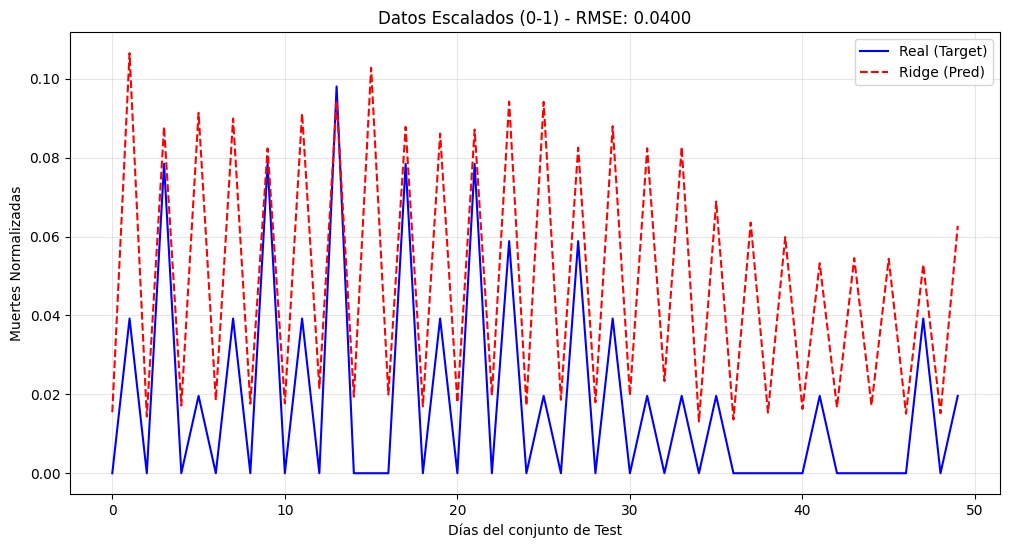

In [18]:
# ================================
# BASELINE RIDGE
# ================================
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# --- 0. RECUPERAR DATOS DE TEST ---
X_test = X[val_idx:]
y_test = y[val_idx:]

# --- 1. PREPARAR INPUT PARA RIDGE (aplanar ventanas) ---
n_samples, window_size, n_features = X.shape
X_flat = X.reshape(n_samples, window_size * n_features)

X_train_flat = X_flat[:train_idx]
y_train_flat = y[:train_idx]

X_test_flat  = X_flat[val_idx:]

# --- 2. ENTRENAR MODELO RIDGE ---
ridge = Ridge(alpha=1.0, fit_intercept=True)
ridge.fit(X_train_flat, y_train_flat)

# --- 3. GENERAR PREDICCIONES ---
y_pred_ridge = ridge.predict(X_test_flat)

# --- 4. DES-ESCALADO A DATOS REALES ---
dummy_pred = np.zeros((len(y_pred_ridge), n_features))
dummy_true = np.zeros((len(y_test), n_features))

dummy_pred[:, target_col_idx] = y_pred_ridge
dummy_true[:, target_col_idx] = y_test

y_pred_real = scaler.inverse_transform(dummy_pred)[:, target_col_idx]
y_true_real = scaler.inverse_transform(dummy_true)[:, target_col_idx]

# --- 5. CÁLCULO DE ERRORES ---
# Escalado (0-1)
mse_scaled = mean_squared_error(y_test, y_pred_ridge)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_ridge)

# # Real (personas)
# mse_real = mean_squared_error(y_true_real, y_pred_real)
# rmse_real = np.sqrt(mse_real)
# mae_real = mean_absolute_error(y_true_real, y_pred_real)

print("--- RESULTADOS RIDGE BASELINE ---")
print(f" SCALED RMSE: {rmse_scaled:.4f} (Adimensional)")
# print(f" REAL   RMSE: {rmse_real:.2f} muertes")
print("-" * 30)
print(f" SCALED MAE:  {mae_scaled:.4f} (Adimensional)")
#print(f" REAL   MAE:  {mae_real:.2f} muertes de error promedio diario")
print("-" * 30)

# --- 6. VISUALIZACIÓN COMPARATIVA ---
# fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# # Gráfica 1: escalada
# axes[0].plot(y_test[:50], label='Real (Target)', color='blue')
# axes[0].plot(y_pred_ridge[:50], label='Ridge (Pred)', color='red', linestyle='--')
# axes[0].set_title(f'A) Datos Escalados (0-1) - RMSE: {rmse_scaled:.4f}')
# axes[0].set_ylabel('Muertes Normalizadas')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # Gráfica 2: datos reales
# axes[1].plot(y_true_real[:50], label='Real (Target)', color='navy')
# axes[1].plot(y_pred_real[:50], label='Ridge (Pred)', color='darkred', linestyle='--')
# axes[1].set_title(f'B) Datos Reales (Personas) - RMSE: {rmse_real:.2f} muertes')
# axes[1].set_ylabel('Número de Fallecidos')
# axes[1].set_xlabel('Días del conjunto de Test')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

#plt.tight_layout()
#plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Dibujar predicción vs real
plt.plot(y_test[:50], label='Real (Target)', color='blue')
plt.plot(y_pred_ridge[:50], label='Ridge (Pred)', color='red', linestyle='--')

# Títulos y etiquetas
plt.title(f'Datos Escalados (0-1) - RMSE: {rmse_scaled:.4f}')
plt.ylabel('Muertes Normalizadas')
plt.xlabel('Días del conjunto de Test')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



###Prueba inicial con MLP

Epoch 1/50 - Train Loss: 0.019750 - Val Loss: 0.005521
Epoch 5/50 - Train Loss: 0.008022 - Val Loss: 0.001660
Epoch 10/50 - Train Loss: 0.005743 - Val Loss: 0.002580
Epoch 15/50 - Train Loss: 0.004528 - Val Loss: 0.002142
Epoch 20/50 - Train Loss: 0.003739 - Val Loss: 0.002318
Epoch 25/50 - Train Loss: 0.005196 - Val Loss: 0.001763
Epoch 30/50 - Train Loss: 0.004947 - Val Loss: 0.001981
Epoch 35/50 - Train Loss: 0.003158 - Val Loss: 0.002403
Epoch 40/50 - Train Loss: 0.003216 - Val Loss: 0.002126
Epoch 45/50 - Train Loss: 0.003101 - Val Loss: 0.002112
Epoch 50/50 - Train Loss: 0.003766 - Val Loss: 0.002958
Entrenamiento completado. Mejor modelo guardado como 'best_mlp_model.pth'.


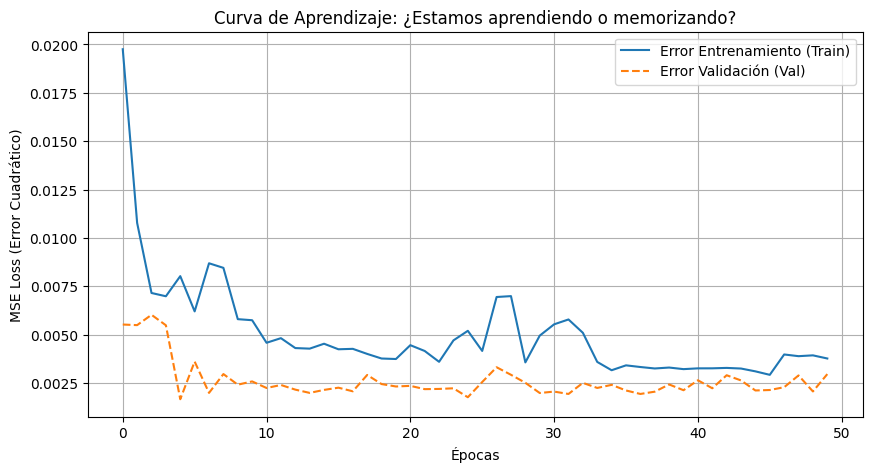

In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50):
    model.train()
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(1, epochs+1):
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                y_pred_val = model(X_val)
                loss_val = criterion(y_pred_val, y_val)
                val_loss += loss_val.item() * X_val.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        model.train()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_mlp_model.pth")

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")

    print("Entrenamiento completado. Mejor modelo guardado como 'best_mlp_model.pth'.")
    # --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Error Entrenamiento (Train)')
    plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
    plt.xlabel('Épocas')
    plt.ylabel('MSE Loss (Error Cuadrático)')
    plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# INSTANCIAR Y ENTRENAR
# ==========================================

input_dim_mlp = X.shape[1] * X.shape[2]  # ventana * features
MLPmodel = COVIDMLP(input_dim=input_dim_mlp, hidden_dims=[128, 64], dropout=0.2)
MLPmodel.to(device)

MLPoptimizer = torch.optim.Adam(MLPmodel.parameters(), lr=0.001)
MLPcriterion = nn.MSELoss()

# Entrenar
train_model(MLPmodel, train_loader, val_loader, MLPcriterion, MLPoptimizer, device, epochs=50)




###Búsqueda de los mejores hiperparámetros para los modelos LSTM


In [20]:
import itertools

def grid_search_total(model_class, model_name, train_loader, val_loader, input_dim, device):
    """
    Busca la mejor combinación de: Learning Rate, Hidden Dim, Num Layers y Dropout.
    """
    print(f"\n Iniciando Grid Search AVANZADO para: {model_name}")

    # --- REJILLA DE BÚSQUEDA ---
    # Intenta mantener pocas opciones para que no tarde horas
    param_grid = {
        'lr': [0.01, 0.001],
        'hidden_dim': [32, 64],
        'num_layers': [1, 2],
        'dropout': [0.2, 0.5]  # 0.2 es estándar, 0.5 es muy agresivo (bueno si hay overfitting)
    }

    # Generamos todas las combinaciones posibles
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f"   -> Se probarán {len(combinations)} combinaciones diferentes.")

    best_loss = float('inf')
    best_params = {}

    for i, params in enumerate(combinations):
        lr = params['lr']
        hd = params['hidden_dim']
        nl = params['num_layers']
        dr = params['dropout']

        print(f"   [{i+1}/{len(combinations)}] Probando: LR={lr}, Hidden={hd}, Layers={nl}, Drop={dr} ...", end="")

        # 1. Instanciar el modelo
        # Para LSTM, GRU, Attention
        model = model_class(input_dim=input_dim, hidden_dim=hd, num_layers=nl, output_dim=1, dropout=dr).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = torch.nn.MSELoss()

        # 2. Entrenar RÁPIDO (5 épocas)
        model.train()
        for epoch in range(5):
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(X)
                if isinstance(out, tuple): out = out[0] # Para attention
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()

        # 3. Validar
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_v, y_v in val_loader:
                X_v, y_v = X_v.to(device), y_v.to(device)
                out_v = model(X_v)
                if isinstance(out_v, tuple): out_v = out_v[0]
                val_loss += criterion(out_v, y_v).item()

        print(f" -> Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_params = params

    print(f"\n GANADOR {model_name}: {best_params}")
    return best_params


Buscamos los mejores hiperparámetros para LSTM, que utilizaremos también para LSTM con atención y a GRU debido a su similitud arquitectónica (redes recurrentes basadas en puertas). Así garantizamos una comparativa ceteris paribus (en igualdad de condiciones).

In [21]:
best_lstm_params = grid_search_total(COVIDLSTM, "LSTM", train_loader, val_loader, input_dim=X.shape[2], device=device)


 Iniciando Grid Search AVANZADO para: LSTM
   -> Se probarán 16 combinaciones diferentes.
   [1/16] Probando: LR=0.01, Hidden=32, Layers=1, Drop=0.2 ...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


 -> Val Loss: 0.1307
   [2/16] Probando: LR=0.01, Hidden=32, Layers=1, Drop=0.5 ...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


 -> Val Loss: 0.0886
   [3/16] Probando: LR=0.01, Hidden=32, Layers=2, Drop=0.2 ... -> Val Loss: 0.0646
   [4/16] Probando: LR=0.01, Hidden=32, Layers=2, Drop=0.5 ... -> Val Loss: 0.0465
   [5/16] Probando: LR=0.01, Hidden=64, Layers=1, Drop=0.2 ... -> Val Loss: 0.0947
   [6/16] Probando: LR=0.01, Hidden=64, Layers=1, Drop=0.5 ... -> Val Loss: 0.1465
   [7/16] Probando: LR=0.01, Hidden=64, Layers=2, Drop=0.2 ... -> Val Loss: 0.0378
   [8/16] Probando: LR=0.01, Hidden=64, Layers=2, Drop=0.5 ... -> Val Loss: 0.0858
   [9/16] Probando: LR=0.001, Hidden=32, Layers=1, Drop=0.2 ... -> Val Loss: 0.0519
   [10/16] Probando: LR=0.001, Hidden=32, Layers=1, Drop=0.5 ... -> Val Loss: 0.0675
   [11/16] Probando: LR=0.001, Hidden=32, Layers=2, Drop=0.2 ... -> Val Loss: 0.0659
   [12/16] Probando: LR=0.001, Hidden=32, Layers=2, Drop=0.5 ... -> Val Loss: 0.0610
   [13/16] Probando: LR=0.001, Hidden=64, Layers=1, Drop=0.2 ... -> Val Loss: 0.0675
   [14/16] Probando: LR=0.001, Hidden=64, Layers=1, Drop=

###Entrenamiento LSTM

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


--- Iniciando entrenamiento en cpu ---
Época [10/100] | Train Loss: 0.00979 | Val Loss (MSE Scaled): 0.00692 | Error Real Aprox: 4.24 personas
Época [20/100] | Train Loss: 0.00541 | Val Loss (MSE Scaled): 0.00417 | Error Real Aprox: 3.29 personas
Época [30/100] | Train Loss: 0.00452 | Val Loss (MSE Scaled): 0.00323 | Error Real Aprox: 2.90 personas
Época [40/100] | Train Loss: 0.00308 | Val Loss (MSE Scaled): 0.00216 | Error Real Aprox: 2.37 personas
Época [50/100] | Train Loss: 0.00492 | Val Loss (MSE Scaled): 0.00279 | Error Real Aprox: 2.69 personas
Época [60/100] | Train Loss: 0.00273 | Val Loss (MSE Scaled): 0.00425 | Error Real Aprox: 3.33 personas
Época [70/100] | Train Loss: 0.00475 | Val Loss (MSE Scaled): 0.00418 | Error Real Aprox: 3.30 personas
Época [80/100] | Train Loss: 0.00327 | Val Loss (MSE Scaled): 0.00425 | Error Real Aprox: 3.33 personas
Época [90/100] | Train Loss: 0.00257 | Val Loss (MSE Scaled): 0.00311 | Error Real Aprox: 2.84 personas
Época [100/100] | Train L

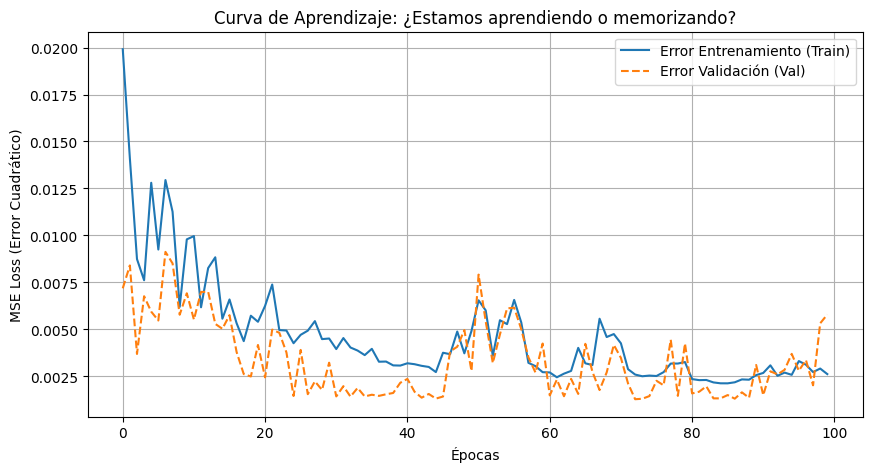

In [44]:
import matplotlib.pyplot as plt
import time

LSTMmodel = COVIDLSTM(input_dim=X.shape[2], hidden_dim=best_lstm_params['hidden_dim'], num_layers=best_lstm_params['num_layers'], output_dim=1, dropout=best_lstm_params['dropout'])
LSTMmodel.to(device)

LSTMcriterion = nn.MSELoss()
LSTMoptimizer = torch.optim.Adam(LSTMmodel.parameters(), lr=best_lstm_params['lr'])

# Configuración del entrenamiento
num_epochs = 100  # Número de veces que la red verá todos los datos
train_losses = []
val_losses = []

print(f"--- Iniciando entrenamiento en {device} ---")
start_time = time.time()

for epoch in range(num_epochs):
    # 1. FASE DE ENTRENAMIENTO
    LSTMmodel.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover a GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # a) Reiniciar gradientes (siempre al principio)
        LSTMoptimizer.zero_grad()

        # b) Predicción (Forward)
        y_pred = LSTMmodel(X_batch)

        # c) Calcular error (Loss)
        loss = LSTMcriterion(y_pred, y_batch)

        # d) Aprender (Backward & Step)
        loss.backward()   # Calcular gradientes
        LSTMoptimizer.step()  # Actualizar pesos

        running_loss += loss.item()

    # Promedio de error en entrenamiento
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

   # 2. FASE DE VALIDACIÓN (DEV)
    LSTMmodel.eval() # Pone el modelo en modo "examen" (desactiva Dropout)
    val_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            pred = LSTMmodel(X_val)
            loss_t = LSTMcriterion(pred, y_val)
            val_loss += loss_t.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular factor de escala (Rango de los datos originales)
    # Si escalaste solo la columna 'y', data_range_ es un array de 1 elemento.
    scale_factor = scaler.data_range_[0]

    # Convertir MSE escalado a RMSE Real (Personas)
    rmse_real_epoch = (avg_val_loss ** 0.5) * scale_factor

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss (MSE Scaled): {avg_val_loss:.5f} | Error Real Aprox: {rmse_real_epoch:.2f} personas")

print(f"\n--- Entrenamiento finalizado en {time.time() - start_time:.1f} segundos ---")

# --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Error Entrenamiento (Train)')
plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Error Cuadrático)')
plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
plt.legend()
plt.grid(True)
plt.show()

###Entrenamiento LSTM + atención

--- Iniciando entrenamiento en cpu ---
Época [10/100] | Train Loss: 0.01596 | Val Loss (MSE Scaled): 0.00499 | Error Real Aprox: 3.60 personas
Época [20/100] | Train Loss: 0.00672 | Val Loss (MSE Scaled): 0.00498 | Error Real Aprox: 3.60 personas
Época [30/100] | Train Loss: 0.00466 | Val Loss (MSE Scaled): 0.00291 | Error Real Aprox: 2.75 personas
Época [40/100] | Train Loss: 0.00445 | Val Loss (MSE Scaled): 0.00310 | Error Real Aprox: 2.84 personas
Época [50/100] | Train Loss: 0.00351 | Val Loss (MSE Scaled): 0.00143 | Error Real Aprox: 1.93 personas
Época [60/100] | Train Loss: 0.00361 | Val Loss (MSE Scaled): 0.00144 | Error Real Aprox: 1.94 personas
Época [70/100] | Train Loss: 0.00293 | Val Loss (MSE Scaled): 0.00131 | Error Real Aprox: 1.85 personas
Época [80/100] | Train Loss: 0.00242 | Val Loss (MSE Scaled): 0.00142 | Error Real Aprox: 1.92 personas
Época [90/100] | Train Loss: 0.00245 | Val Loss (MSE Scaled): 0.00172 | Error Real Aprox: 2.12 personas
Época [100/100] | Train L

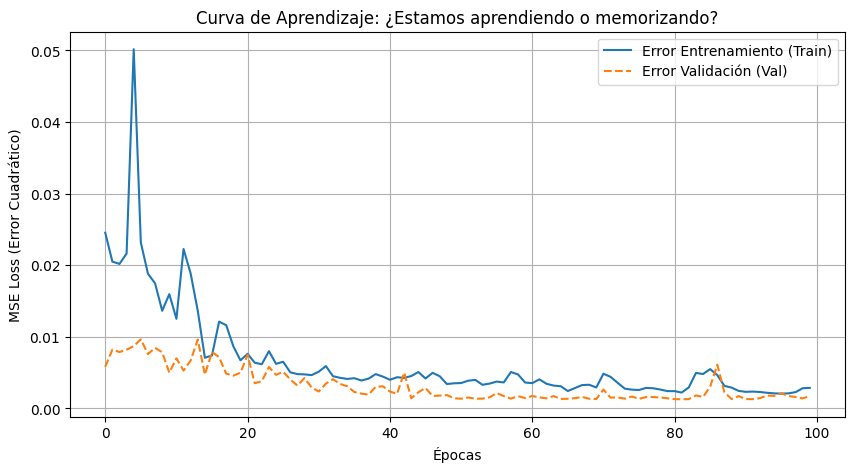

In [23]:
import matplotlib.pyplot as plt
import time

LSTMAttmodel = COVIDLSTMWithAttention(input_dim=X.shape[2], hidden_dim=best_lstm_params['hidden_dim'], num_layers=best_lstm_params['num_layers'], output_dim=1, dropout=best_lstm_params['dropout'])
LSTMAttmodel.to(device)

LSTMAttcriterion = nn.MSELoss()
LSTMAttoptimizer = torch.optim.Adam(LSTMAttmodel.parameters(), lr=best_lstm_params['lr'])

# Configuración del entrenamiento
num_epochs = 100  # Número de veces que la red verá todos los datos
train_losses = []
val_losses = []

print(f"--- Iniciando entrenamiento en {device} ---")
start_time = time.time()

for epoch in range(num_epochs):
    # 1. FASE DE ENTRENAMIENTO
    LSTMAttmodel.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover a GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # a) Reiniciar gradientes (siempre al principio)
        LSTMAttoptimizer.zero_grad()

        # b) Predicción (Forward)
        y_pred = LSTMAttmodel(X_batch)

        # c) Calcular error (Loss)
        loss = LSTMAttcriterion(y_pred, y_batch)

        # d) Aprender (Backward & Step)
        loss.backward()   # Calcular gradientes
        LSTMAttoptimizer.step()  # Actualizar pesos

        running_loss += loss.item()

    # Promedio de error en entrenamiento
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

   # 2. FASE DE VALIDACIÓN (DEV)
    LSTMAttmodel.eval() # Pone el modelo en modo "examen" (desactiva Dropout)
    val_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            pred = LSTMAttmodel(X_val)
            loss_t = LSTMAttcriterion(pred, y_val)
            val_loss += loss_t.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular factor de escala (Rango de los datos originales)
    # Si escalaste solo la columna 'y', data_range_ es un array de 1 elemento.
    scale_factor = scaler.data_range_[0]

    # Convertir MSE escalado a RMSE Real (Personas)
    rmse_real_epoch = (avg_val_loss ** 0.5) * scale_factor

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss (MSE Scaled): {avg_val_loss:.5f} | Error Real Aprox: {rmse_real_epoch:.2f} personas")

print(f"\n--- Entrenamiento finalizado en {time.time() - start_time:.1f} segundos ---")

# --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Error Entrenamiento (Train)')
plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Error Cuadrático)')
plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
plt.legend()
plt.grid(True)
plt.show()


###Entrenamiento GRU

--- Iniciando entrenamiento en cpu ---
Época [10/100] | Train Loss: 0.01042 | Val Loss (MSE Scaled): 0.00155 | Error Real Aprox: 2.01 personas
Época [20/100] | Train Loss: 0.00712 | Val Loss (MSE Scaled): 0.00238 | Error Real Aprox: 2.49 personas
Época [30/100] | Train Loss: 0.00511 | Val Loss (MSE Scaled): 0.00183 | Error Real Aprox: 2.18 personas
Época [40/100] | Train Loss: 0.00344 | Val Loss (MSE Scaled): 0.00189 | Error Real Aprox: 2.22 personas
Época [50/100] | Train Loss: 0.00526 | Val Loss (MSE Scaled): 0.00494 | Error Real Aprox: 3.58 personas
Época [60/100] | Train Loss: 0.00483 | Val Loss (MSE Scaled): 0.00943 | Error Real Aprox: 4.95 personas
Época [70/100] | Train Loss: 0.00346 | Val Loss (MSE Scaled): 0.00170 | Error Real Aprox: 2.10 personas
Época [80/100] | Train Loss: 0.00338 | Val Loss (MSE Scaled): 0.00204 | Error Real Aprox: 2.30 personas
Época [90/100] | Train Loss: 0.00398 | Val Loss (MSE Scaled): 0.00169 | Error Real Aprox: 2.10 personas
Época [100/100] | Train L

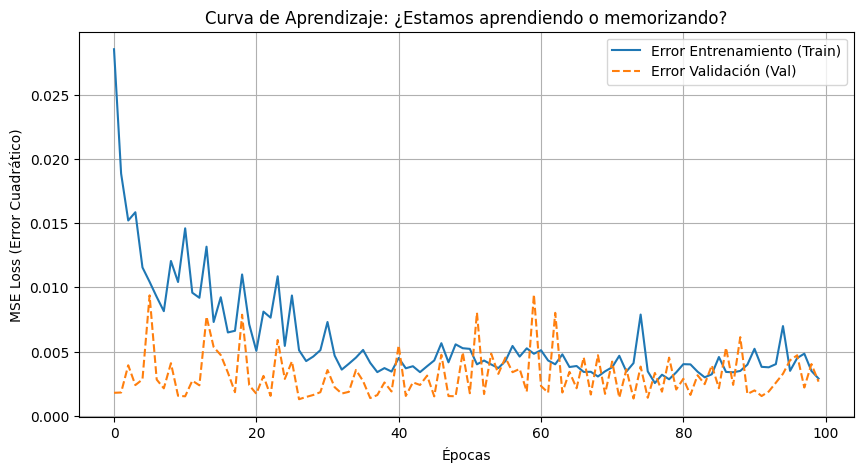

In [24]:
import matplotlib.pyplot as plt
import time

GRUmodel = COVIDGRU(input_dim=X.shape[2], hidden_dim=best_lstm_params['hidden_dim'], num_layers=best_lstm_params['num_layers'], output_dim=1, dropout=best_lstm_params['dropout'])
GRUmodel.to(device)

GRUcriterion = nn.MSELoss()
GRUoptimizer = torch.optim.Adam(GRUmodel.parameters(), lr=best_lstm_params['lr'])

# Configuración del entrenamiento
num_epochs = 100  # Número de veces que la red verá todos los datos
train_losses = []
val_losses = []

print(f"--- Iniciando entrenamiento en {device} ---")
start_time = time.time()

for epoch in range(num_epochs):
    # 1. FASE DE ENTRENAMIENTO
    GRUmodel.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover a GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # a) Reiniciar gradientes (siempre al principio)
        GRUoptimizer.zero_grad()

        # b) Predicción (Forward)
        y_pred = GRUmodel(X_batch)

        # c) Calcular error (Loss)
        loss = GRUcriterion(y_pred, y_batch)

        # d) Aprender (Backward & Step)
        loss.backward()   # Calcular gradientes
        GRUoptimizer.step()  # Actualizar pesos

        running_loss += loss.item()

    # Promedio de error en entrenamiento
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

   # 2. FASE DE VALIDACIÓN (DEV)
    GRUmodel.eval() # Pone el modelo en modo "examen" (desactiva Dropout)
    val_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            pred = GRUmodel(X_val)
            loss_t = GRUcriterion(pred, y_val)
            val_loss += loss_t.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular factor de escala (Rango de los datos originales)
    # Si escalaste solo la columna 'y', data_range_ es un array de 1 elemento.
    scale_factor = scaler.data_range_[0]

    # Convertir MSE escalado a RMSE Real (Personas)
    rmse_real_epoch = (avg_val_loss ** 0.5) * scale_factor

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss (MSE Scaled): {avg_val_loss:.5f} | Error Real Aprox: {rmse_real_epoch:.2f} personas")

print(f"\n--- Entrenamiento finalizado en {time.time() - start_time:.1f} segundos ---")

# --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Error Entrenamiento (Train)')
plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Error Cuadrático)')
plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
plt.legend()
plt.grid(True)
plt.show()


##Opción 2: Datos reordenados aleatoriamente (de 7 en 7)

###Preprocesado de datos (normalización y ventanas)

In [25]:
# ==========================================
# 4. PREPARACIÓN PARA PYTORCH (shuffle + escalado solo con train)
# ==========================================

WINDOW_SIZE = 7
target_col_idx = features_cols.index('target_muertes')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Crear secuencias ---
data_scaled_raw = df_master[features_cols].values
X, y = [], []
for i in range(len(data_scaled_raw) - WINDOW_SIZE):
    X.append(data_scaled_raw[i:i+WINDOW_SIZE])
    y.append(data_scaled_raw[i+WINDOW_SIZE, target_col_idx])
X = np.array(X)
y = np.array(y)

# --- 2. Shuffle aleatorio de índices ---
indices = np.arange(len(X))
np.random.shuffle(indices)
X, y = X[indices], y[indices]

# --- 3. Dividir según porcentajes ---
n_samples = len(X)
train_end = int(n_samples * 0.7)
val_end   = int(n_samples * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]

# --- 4. Escalar solo con train ---
n_features = X_train.shape[2]
scaler = MinMaxScaler()
X_train_reshaped = X_train.reshape(-1, n_features)
scaler.fit(X_train_reshaped)
X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

# --- 5. Convertir a tensores ---
train_dataset = TensorDataset(torch.from_numpy(X_train_scaled).float().to(device),
                              torch.from_numpy(y_train).float().to(device))
val_dataset   = TensorDataset(torch.from_numpy(X_val_scaled).float().to(device),
                              torch.from_numpy(y_val).float().to(device))
test_dataset  = TensorDataset(torch.from_numpy(X_test_scaled).float().to(device),
                              torch.from_numpy(y_test).float().to(device))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\n--- Datos Listos ---")
print(f"X Train: {X_train_scaled.shape}, X Val: {X_val_scaled.shape}, X Test: {X_test_scaled.shape}")
print(f"Dispositivo: {device}")



--- Datos Listos ---
X Train: (1701, 7, 35), X Val: (365, 7, 35), X Test: (365, 7, 35)
Dispositivo: cpu


###Baseline: las muertes de un día son iguales a las muertes del día anterior

--- RESULTADOS BASELINE (MODELO DE PERSISTENCIA) ---
 SCALED MAE:  5.6741 (Adimensional)
------------------------------


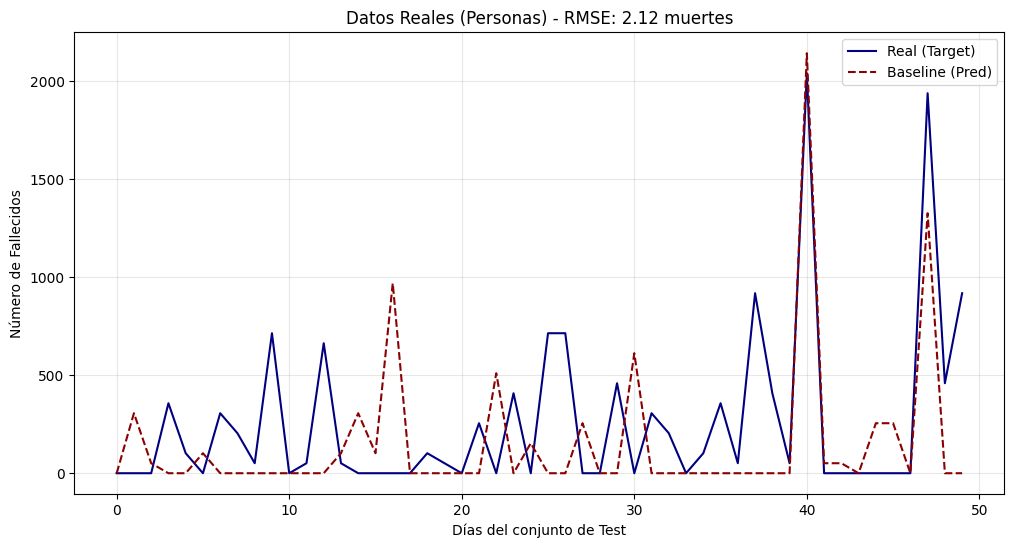

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# --- 0. RECUPERAR DATOS DE TEST ---
X_test = X[val_idx:]
y_test = y[val_idx:]

# --- 1. GENERAR PREDICCIONES DEL BASELINE ---
# La predicción es el valor del último día de la ventana (index -1)
y_pred_baseline = X_test[:, -1, target_col_idx]

# ==========================================
# 2. DES-ESCALADO (VOLVER A MUNDO REAL)
# ==========================================

# Necesitamos saber cuántas features tenía el scaler original
n_features = X_test.shape[2]

# Creamos matrices "dummy" (vacías) con la forma correcta para engañar al scaler
dummy_pred = np.zeros((len(y_pred_baseline), n_features))
dummy_true = np.zeros((len(y_test), n_features))

# Rellenamos SOLO la columna de las muertes (target_col_idx)
dummy_pred[:, target_col_idx] = y_pred_baseline
dummy_true[:, target_col_idx] = y_test

# Aplicamos la inversa
# Y extraemos solo la columna que nos interesa
y_pred_real = scaler.inverse_transform(dummy_pred)[:, target_col_idx]
y_true_real = scaler.inverse_transform(dummy_true)[:, target_col_idx]

# ==========================================
# 3. CÁLCULO DE ERRORES
# ==========================================

# A. Error Escalado (0-1)
mse_scaled = mean_squared_error(y_test, y_pred_baseline)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_baseline)

# B. Error Real (Personas)
# mse_real = mean_squared_error(y_true_real, y_pred_real)
# rmse_real = np.sqrt(mse_real)
# mae_real = mean_absolute_error(y_true_real, y_pred_real)

print("--- RESULTADOS BASELINE (MODELO DE PERSISTENCIA) ---")
#print(f" SCALED RMSE: {rmse_scaled:.4f} (Adimensional)")
#print(f" REAL   RMSE: {rmse_real:.2f} muertes")
#print("-" * 30)
print(f" SCALED MAE:  {mae_scaled:.4f} (Adimensional)")
#print(f" REAL   MAE:  {mae_real:.2f} muertes de error promedio diario")
print("-" * 30)

# ==========================================
# 4. VISUALIZACIÓN COMPARATIVA
# ==========================================

# fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# # GRÁFICA 1: ESCALADA
# axes[0].plot(y_test[:50], label='Real (Target)', color='blue')
# axes[0].plot(y_pred_baseline[:50], label='Baseline (Pred)', color='red', linestyle='--')
# axes[0].set_title(f'A) Datos Escalados (0-1) - RMSE: {rmse_scaled:.4f}')
# axes[0].set_ylabel('Muertes Normalizadas')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# GRÁFICA 2: REAL
# axes[1].plot(y_true_real[:50], label='Real (Target)', color='navy')
# axes[1].plot(y_pred_real[:50], label='Baseline (Pred)', color='darkred', linestyle='--')
# axes[1].set_title(f'B) Datos Reales (Personas) - RMSE: {rmse_real:.2f} muertes')
# axes[1].set_ylabel('Número de Fallecidos')
# axes[1].set_xlabel('Días del conjunto de Test')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Dibujar predicción vs real (datos reales)
plt.plot(y_true_real[:50], label='Real (Target)', color='navy')
plt.plot(y_pred_real[:50], label='Baseline (Pred)', color='darkred', linestyle='--')

# Títulos y etiquetas
plt.title(f'Datos Reales (Personas) - RMSE: {rmse_real:.2f} muertes')
plt.ylabel('Número de Fallecidos')
plt.xlabel('Días del conjunto de Test')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


###Baseline: las muertes de un día son iguales a las muertes del día anterior

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.56682e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


--- RESULTADOS RIDGE BASELINE ---
 SCALED RMSE: 2.0695 (Adimensional)
------------------------------
 SCALED MAE:  1.2358 (Adimensional)
------------------------------


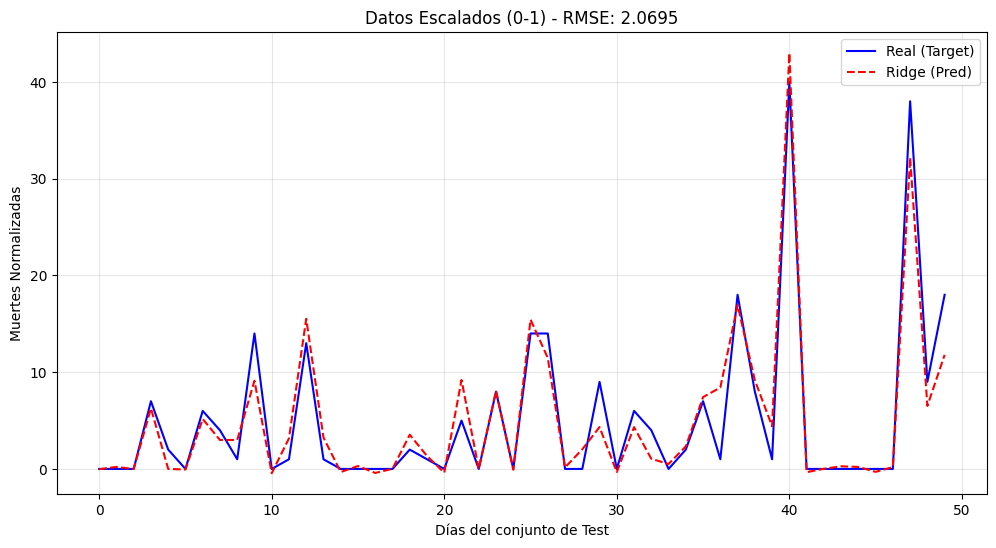

In [27]:
# ================================
# BASELINE RIDGE
# ================================
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# --- 0. RECUPERAR DATOS DE TEST ---
X_test = X[val_idx:]
y_test = y[val_idx:]

# --- 1. PREPARAR INPUT PARA RIDGE (aplanar ventanas) ---
n_samples, window_size, n_features = X.shape
X_flat = X.reshape(n_samples, window_size * n_features)

X_train_flat = X_flat[:train_idx]
y_train_flat = y[:train_idx]

X_test_flat  = X_flat[val_idx:]

# --- 2. ENTRENAR MODELO RIDGE ---
ridge = Ridge(alpha=1.0, fit_intercept=True)
ridge.fit(X_train_flat, y_train_flat)

# --- 3. GENERAR PREDICCIONES ---
y_pred_ridge = ridge.predict(X_test_flat)

# --- 4. DES-ESCALADO A DATOS REALES ---
dummy_pred = np.zeros((len(y_pred_ridge), n_features))
dummy_true = np.zeros((len(y_test), n_features))

dummy_pred[:, target_col_idx] = y_pred_ridge
dummy_true[:, target_col_idx] = y_test

y_pred_real = scaler.inverse_transform(dummy_pred)[:, target_col_idx]
y_true_real = scaler.inverse_transform(dummy_true)[:, target_col_idx]

# --- 5. CÁLCULO DE ERRORES ---
# Escalado (0-1)
mse_scaled = mean_squared_error(y_test, y_pred_ridge)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test, y_pred_ridge)

# # Real (personas)
# mse_real = mean_squared_error(y_true_real, y_pred_real)
# rmse_real = np.sqrt(mse_real)
# mae_real = mean_absolute_error(y_true_real, y_pred_real)

print("--- RESULTADOS RIDGE BASELINE ---")
print(f" SCALED RMSE: {rmse_scaled:.4f} (Adimensional)")
# print(f" REAL   RMSE: {rmse_real:.2f} muertes")
print("-" * 30)
print(f" SCALED MAE:  {mae_scaled:.4f} (Adimensional)")
#print(f" REAL   MAE:  {mae_real:.2f} muertes de error promedio diario")
print("-" * 30)

# --- 6. VISUALIZACIÓN COMPARATIVA ---
# fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# # Gráfica 1: escalada
# axes[0].plot(y_test[:50], label='Real (Target)', color='blue')
# axes[0].plot(y_pred_ridge[:50], label='Ridge (Pred)', color='red', linestyle='--')
# axes[0].set_title(f'A) Datos Escalados (0-1) - RMSE: {rmse_scaled:.4f}')
# axes[0].set_ylabel('Muertes Normalizadas')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # Gráfica 2: datos reales
# axes[1].plot(y_true_real[:50], label='Real (Target)', color='navy')
# axes[1].plot(y_pred_real[:50], label='Ridge (Pred)', color='darkred', linestyle='--')
# axes[1].set_title(f'B) Datos Reales (Personas) - RMSE: {rmse_real:.2f} muertes')
# axes[1].set_ylabel('Número de Fallecidos')
# axes[1].set_xlabel('Días del conjunto de Test')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

#plt.tight_layout()
#plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Dibujar predicción vs real
plt.plot(y_test[:50], label='Real (Target)', color='blue')
plt.plot(y_pred_ridge[:50], label='Ridge (Pred)', color='red', linestyle='--')

# Títulos y etiquetas
plt.title(f'Datos Escalados (0-1) - RMSE: {rmse_scaled:.4f}')
plt.ylabel('Muertes Normalizadas')
plt.xlabel('Días del conjunto de Test')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()



###Prueba inicial con MLP

Epoch 1/50 - Train Loss: 38.524954 - Val Loss: 19.907985
Epoch 5/50 - Train Loss: 7.596411 - Val Loss: 7.102512
Epoch 10/50 - Train Loss: 7.083250 - Val Loss: 5.462229
Epoch 15/50 - Train Loss: 6.626093 - Val Loss: 5.115349
Epoch 20/50 - Train Loss: 6.304238 - Val Loss: 4.596108
Epoch 25/50 - Train Loss: 6.294263 - Val Loss: 4.316364
Epoch 30/50 - Train Loss: 5.889853 - Val Loss: 4.599143
Epoch 35/50 - Train Loss: 5.459154 - Val Loss: 4.186481
Epoch 40/50 - Train Loss: 5.742714 - Val Loss: 4.644217
Epoch 45/50 - Train Loss: 5.085300 - Val Loss: 5.022908
Epoch 50/50 - Train Loss: 5.298499 - Val Loss: 4.031951
Entrenamiento completado. Mejor modelo guardado como 'best_mlp_model.pth'.


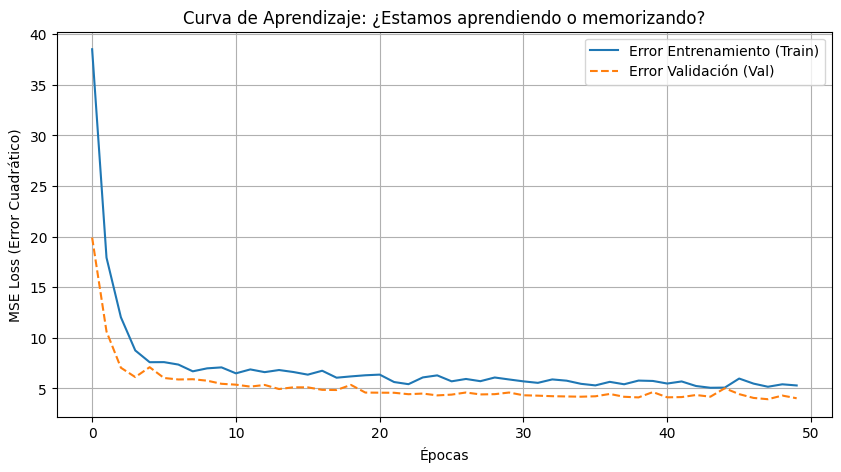

In [28]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50):
    model.train()
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(1, epochs+1):
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                y_pred_val = model(X_val)
                loss_val = criterion(y_pred_val, y_val)
                val_loss += loss_val.item() * X_val.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        model.train()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_mlp_model.pth")

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")

    print("Entrenamiento completado. Mejor modelo guardado como 'best_mlp_model.pth'.")
    # --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Error Entrenamiento (Train)')
    plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
    plt.xlabel('Épocas')
    plt.ylabel('MSE Loss (Error Cuadrático)')
    plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# INSTANCIAR Y ENTRENAR
# ==========================================

input_dim_mlp = X.shape[1] * X.shape[2]  # ventana * features
MLPmodel = COVIDMLP(input_dim=input_dim_mlp, hidden_dims=[128, 64], dropout=0.2)
MLPmodel.to(device)

MLPoptimizer = torch.optim.Adam(MLPmodel.parameters(), lr=0.001)
MLPcriterion = nn.MSELoss()

# Entrenar
train_model(MLPmodel, train_loader, val_loader, MLPcriterion, MLPoptimizer, device, epochs=50)


# def test_model(model, test_loader, criterion, device):
#     model.eval()
#     test_loss = 0.0
#     y_true, y_pred_list = [], []

#     with torch.no_grad():
#         for X_batch, y_batch in test_loader:
#             y_pred_batch = model(X_batch)
#             loss = criterion(y_pred_batch, y_batch)
#             test_loss += loss.item() * X_batch.size(0)
#             y_true.extend(y_batch.cpu().numpy())
#             y_pred_list.extend(y_pred_batch.cpu().numpy())

#     test_loss /= len(test_loader.dataset)
#     print(f"Test Loss (MSE): {test_loss:.6f}")
#     return np.array(y_true), np.array(y_pred_list)


# Test
# y_true, y_pred = test_model(MLPmodel, test_loader, MLPcriterion, device)




###Búsqueda de los mejores hiperparámetros para los modelos LSTM


In [29]:
import itertools

def grid_search_total(model_class, model_name, train_loader, val_loader, input_dim, device):
    """
    Busca la mejor combinación de: Learning Rate, Hidden Dim, Num Layers y Dropout.
    """
    print(f"\n Iniciando Grid Search AVANZADO para: {model_name}")

    # --- REJILLA DE BÚSQUEDA ---
    # Intenta mantener pocas opciones para que no tarde horas
    param_grid = {
        'lr': [0.01, 0.001],
        'hidden_dim': [32, 64],
        'num_layers': [1, 2],
        'dropout': [0.2, 0.5]  # 0.2 es estándar, 0.5 es muy agresivo (bueno si hay overfitting)
    }

    # Generamos todas las combinaciones posibles
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    print(f"   -> Se probarán {len(combinations)} combinaciones diferentes.")

    best_loss = float('inf')
    best_params = {}

    for i, params in enumerate(combinations):
        lr = params['lr']
        hd = params['hidden_dim']
        nl = params['num_layers']
        dr = params['dropout']

        print(f"   [{i+1}/{len(combinations)}] Probando: LR={lr}, Hidden={hd}, Layers={nl}, Drop={dr} ...", end="")

        # 1. Instanciar el modelo
        # Para LSTM, GRU, Attention
        model = model_class(input_dim=input_dim, hidden_dim=hd, num_layers=nl, output_dim=1, dropout=dr).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = torch.nn.MSELoss()

        # 2. Entrenar RÁPIDO (5 épocas)
        model.train()
        for epoch in range(5):
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(X)
                if isinstance(out, tuple): out = out[0] # Para attention
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()

        # 3. Validar
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_v, y_v in val_loader:
                X_v, y_v = X_v.to(device), y_v.to(device)
                out_v = model(X_v)
                if isinstance(out_v, tuple): out_v = out_v[0]
                val_loss += criterion(out_v, y_v).item()

        print(f" -> Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_params = params

    print(f"\n GANADOR {model_name}: {best_params}")
    return best_params


Buscamos los mejores hiperparámetros para LSTM, que utilizaremos también para LSTM con atención y a GRU debido a su similitud arquitectónica (redes recurrentes basadas en puertas). Así garantizamos una comparativa ceteris paribus (en igualdad de condiciones).

In [30]:
best_lstm_params = grid_search_total(COVIDLSTM, "LSTM", train_loader, val_loader, input_dim=X.shape[2], device=device)


 Iniciando Grid Search AVANZADO para: LSTM
   -> Se probarán 16 combinaciones diferentes.
   [1/16] Probando: LR=0.01, Hidden=32, Layers=1, Drop=0.2 ...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


 -> Val Loss: 119.3360
   [2/16] Probando: LR=0.01, Hidden=32, Layers=1, Drop=0.5 ...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


 -> Val Loss: 96.8545
   [3/16] Probando: LR=0.01, Hidden=32, Layers=2, Drop=0.2 ... -> Val Loss: 118.9053
   [4/16] Probando: LR=0.01, Hidden=32, Layers=2, Drop=0.5 ... -> Val Loss: 114.6716
   [5/16] Probando: LR=0.01, Hidden=64, Layers=1, Drop=0.2 ... -> Val Loss: 79.0465
   [6/16] Probando: LR=0.01, Hidden=64, Layers=1, Drop=0.5 ... -> Val Loss: 76.4886
   [7/16] Probando: LR=0.01, Hidden=64, Layers=2, Drop=0.2 ... -> Val Loss: 82.6505
   [8/16] Probando: LR=0.01, Hidden=64, Layers=2, Drop=0.5 ... -> Val Loss: 82.0056
   [9/16] Probando: LR=0.001, Hidden=32, Layers=1, Drop=0.2 ... -> Val Loss: 351.0495
   [10/16] Probando: LR=0.001, Hidden=32, Layers=1, Drop=0.5 ... -> Val Loss: 334.9138
   [11/16] Probando: LR=0.001, Hidden=32, Layers=2, Drop=0.2 ... -> Val Loss: 373.9376
   [12/16] Probando: LR=0.001, Hidden=32, Layers=2, Drop=0.5 ... -> Val Loss: 343.4766
   [13/16] Probando: LR=0.001, Hidden=64, Layers=1, Drop=0.2 ... -> Val Loss: 222.1654
   [14/16] Probando: LR=0.001, Hidden=

###Entrenamiento LSTM

--- Iniciando entrenamiento en cpu ---
Época [10/100] | Train Loss: 6.69319 | Val Loss (MSE Scaled): 8.04674 | Error Real Aprox: 144.67 personas
Época [20/100] | Train Loss: 4.97668 | Val Loss (MSE Scaled): 4.22282 | Error Real Aprox: 104.80 personas
Época [30/100] | Train Loss: 4.68730 | Val Loss (MSE Scaled): 4.02228 | Error Real Aprox: 102.28 personas
Época [40/100] | Train Loss: 4.07611 | Val Loss (MSE Scaled): 4.34766 | Error Real Aprox: 106.34 personas
Época [50/100] | Train Loss: 3.68056 | Val Loss (MSE Scaled): 4.00979 | Error Real Aprox: 102.12 personas
Época [60/100] | Train Loss: 4.67453 | Val Loss (MSE Scaled): 4.05428 | Error Real Aprox: 102.69 personas
Época [70/100] | Train Loss: 3.90325 | Val Loss (MSE Scaled): 5.39561 | Error Real Aprox: 118.47 personas
Época [80/100] | Train Loss: 3.14244 | Val Loss (MSE Scaled): 4.64985 | Error Real Aprox: 109.97 personas
Época [90/100] | Train Loss: 2.75850 | Val Loss (MSE Scaled): 4.47350 | Error Real Aprox: 107.87 personas
Época [

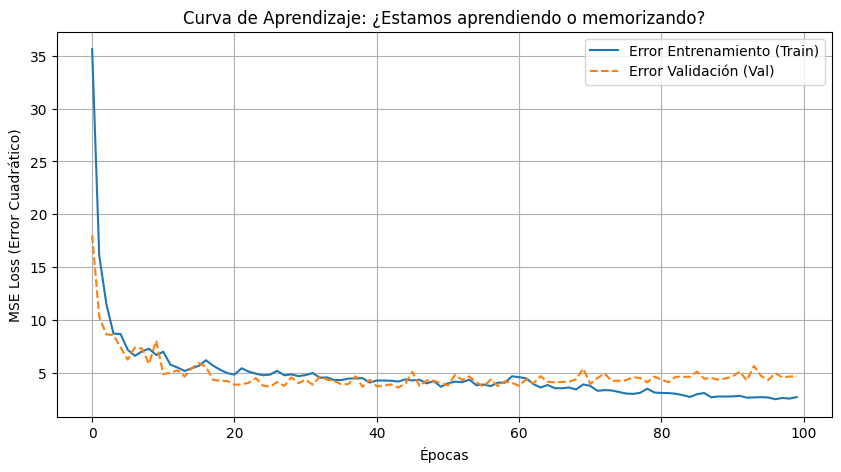


--- MÉTRICAS EN ESCALA REAL ---
RMSE real: 110.11 muertes/día
MAE real : 60.24 muertes/día


In [31]:
import matplotlib.pyplot as plt
import time

LSTMmodel = COVIDLSTM(input_dim=X.shape[2], hidden_dim=best_lstm_params['hidden_dim'], num_layers=best_lstm_params['num_layers'], output_dim=1, dropout=best_lstm_params['dropout'])
LSTMmodel.to(device)

LSTMcriterion = nn.MSELoss()
LSTMoptimizer = torch.optim.Adam(LSTMmodel.parameters(), lr=best_lstm_params['lr'])

# Configuración del entrenamiento
num_epochs = 100  # Número de veces que la red verá todos los datos
train_losses = []
val_losses = []

print(f"--- Iniciando entrenamiento en {device} ---")
start_time = time.time()

for epoch in range(num_epochs):
    # 1. FASE DE ENTRENAMIENTO
    LSTMmodel.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover a GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # a) Reiniciar gradientes (siempre al principio)
        LSTMoptimizer.zero_grad()

        # b) Predicción (Forward)
        y_pred = LSTMmodel(X_batch)

        # c) Calcular error (Loss)
        loss = LSTMcriterion(y_pred, y_batch)

        # d) Aprender (Backward & Step)
        loss.backward()   # Calcular gradientes
        LSTMoptimizer.step()  # Actualizar pesos

        running_loss += loss.item()

    # Promedio de error en entrenamiento
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

   # 2. FASE DE VALIDACIÓN (DEV)
    LSTMmodel.eval() # Pone el modelo en modo "examen" (desactiva Dropout)
    val_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            pred = LSTMmodel(X_val)
            loss_t = LSTMcriterion(pred, y_val)
            val_loss += loss_t.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular factor de escala (Rango de los datos originales)
    # Si escalaste solo la columna 'y', data_range_ es un array de 1 elemento.
    scale_factor = scaler.data_range_[0]

    # Convertir MSE escalado a RMSE Real (Personas)
    rmse_real_epoch = (avg_val_loss ** 0.5) * scale_factor

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss (MSE Scaled): {avg_val_loss:.5f} | Error Real Aprox: {rmse_real_epoch:.2f} personas")

# --- GUARDAR HISTORIAL PARA COMPARAR LUEGO ---
lstm_val_history = val_losses.copy()

print(f"\n--- Entrenamiento finalizado en {time.time() - start_time:.1f} segundos ---")

# --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Error Entrenamiento (Train)')
plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Error Cuadrático)')
plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
plt.legend()
plt.grid(True)
plt.show()


# # ==========================================
# # 4. PREDICCIONES EN TEST
# # ==========================================

LSTMmodel.eval()

preds = []
targets = []

with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        y_pred = LSTMmodel(X_test)

        preds.append(y_pred.cpu().numpy())
        targets.append(y_test.cpu().numpy())

preds = np.concatenate(preds)
targets = np.concatenate(targets)

# ==========================================
# 5. DESESCALADO A MUERTES REALES
# ==========================================

n_features = data_scaled.shape[1]

dummy_preds = np.zeros((len(preds), n_features))
dummy_true  = np.zeros((len(targets), n_features))

dummy_preds[:, target_col_idx] = preds
dummy_true[:, target_col_idx]  = targets

preds_real = scaler.inverse_transform(dummy_preds)[:, target_col_idx]
targets_real = scaler.inverse_transform(dummy_true)[:, target_col_idx]

# ==========================================
# 6. MÉTRICAS REALES
# ==========================================

rmse_real = np.sqrt(np.mean((preds_real - targets_real) ** 2))
mae_real  = np.mean(np.abs(preds_real - targets_real))

print("\n--- MÉTRICAS EN ESCALA REAL ---")
print(f"RMSE real: {rmse_real:.2f} muertes/día")
print(f"MAE real : {mae_real:.2f} muertes/día")


###Entrenamiento LSTM + atención

--- Iniciando entrenamiento en cpu ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Época [10/100] | Train Loss: 5.88869 | Val Loss (MSE Scaled): 4.70349 | Error Real Aprox: 110.61 personas
Época [20/100] | Train Loss: 4.80927 | Val Loss (MSE Scaled): 4.50297 | Error Real Aprox: 108.22 personas
Época [30/100] | Train Loss: 4.41080 | Val Loss (MSE Scaled): 3.70355 | Error Real Aprox: 98.15 personas
Época [40/100] | Train Loss: 4.39895 | Val Loss (MSE Scaled): 3.80402 | Error Real Aprox: 99.47 personas
Época [50/100] | Train Loss: 5.21076 | Val Loss (MSE Scaled): 3.80038 | Error Real Aprox: 99.42 personas
Época [60/100] | Train Loss: 3.49105 | Val Loss (MSE Scaled): 4.75507 | Error Real Aprox: 111.21 personas
Época [70/100] | Train Loss: 3.38317 | Val Loss (MSE Scaled): 4.52056 | Error Real Aprox: 108.43 personas
Época [80/100] | Train Loss: 3.14686 | Val Loss (MSE Scaled): 4.69311 | Error Real Aprox: 110.48 personas
Época [90/100] | Train Loss: 2.62773 | Val Loss (MSE Scaled): 4.75134 | Error Real Aprox: 111.17 personas
Época [100/100] | Train Loss: 2.96183 | Val Loss 

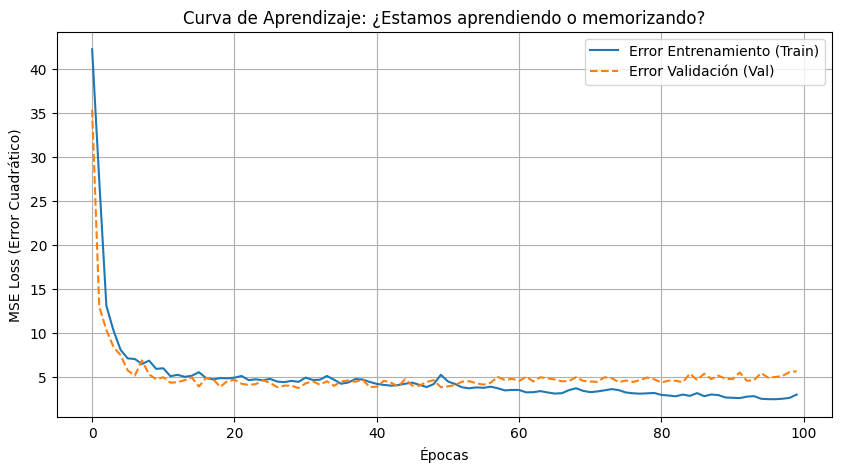

In [32]:
import matplotlib.pyplot as plt
import time

LSTMAttmodel = COVIDLSTMWithAttention(input_dim=X.shape[2], hidden_dim=best_lstm_params['hidden_dim'], num_layers=best_lstm_params['num_layers'], output_dim=1, dropout=best_lstm_params['dropout'])
LSTMAttmodel.to(device)

LSTMAttcriterion = nn.MSELoss()
LSTMAttoptimizer = torch.optim.Adam(LSTMAttmodel.parameters(), lr=best_lstm_params['lr'])

# Configuración del entrenamiento
num_epochs = 100  # Número de veces que la red verá todos los datos
train_losses = []
val_losses = []

print(f"--- Iniciando entrenamiento en {device} ---")
start_time = time.time()

for epoch in range(num_epochs):
    # 1. FASE DE ENTRENAMIENTO
    LSTMAttmodel.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover a GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # a) Reiniciar gradientes (siempre al principio)
        LSTMAttoptimizer.zero_grad()

        # b) Predicción (Forward)
        y_pred = LSTMAttmodel(X_batch)

        # c) Calcular error (Loss)
        loss = LSTMAttcriterion(y_pred, y_batch)

        # d) Aprender (Backward & Step)
        loss.backward()   # Calcular gradientes
        LSTMAttoptimizer.step()  # Actualizar pesos

        running_loss += loss.item()

    # Promedio de error en entrenamiento
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

   # 2. FASE DE VALIDACIÓN (DEV)
    LSTMAttmodel.eval() # Pone el modelo en modo "examen" (desactiva Dropout)
    val_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            pred = LSTMAttmodel(X_val)
            loss_t = LSTMAttcriterion(pred, y_val)
            val_loss += loss_t.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular factor de escala (Rango de los datos originales)
    # Si escalaste solo la columna 'y', data_range_ es un array de 1 elemento.
    scale_factor = scaler.data_range_[0]

    # Convertir MSE escalado a RMSE Real (Personas)
    rmse_real_epoch = (avg_val_loss ** 0.5) * scale_factor

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss (MSE Scaled): {avg_val_loss:.5f} | Error Real Aprox: {rmse_real_epoch:.2f} personas")

print(f"\n--- Entrenamiento finalizado en {time.time() - start_time:.1f} segundos ---")

# --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Error Entrenamiento (Train)')
plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Error Cuadrático)')
plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
plt.legend()
plt.grid(True)
plt.show()


###Entrenamiento GRU

--- Iniciando entrenamiento en cpu ---
Época [10/100] | Train Loss: 5.78133 | Val Loss (MSE Scaled): 4.63829 | Error Real Aprox: 109.84 personas
Época [20/100] | Train Loss: 4.54388 | Val Loss (MSE Scaled): 4.53283 | Error Real Aprox: 108.58 personas
Época [30/100] | Train Loss: 4.36131 | Val Loss (MSE Scaled): 4.52361 | Error Real Aprox: 108.47 personas
Época [40/100] | Train Loss: 4.04720 | Val Loss (MSE Scaled): 4.25060 | Error Real Aprox: 105.15 personas
Época [50/100] | Train Loss: 3.12597 | Val Loss (MSE Scaled): 5.10793 | Error Real Aprox: 115.26 personas
Época [60/100] | Train Loss: 3.03503 | Val Loss (MSE Scaled): 4.70818 | Error Real Aprox: 110.66 personas
Época [70/100] | Train Loss: 2.58662 | Val Loss (MSE Scaled): 5.54060 | Error Real Aprox: 120.05 personas
Época [80/100] | Train Loss: 2.36836 | Val Loss (MSE Scaled): 5.72338 | Error Real Aprox: 122.01 personas
Época [90/100] | Train Loss: 1.80448 | Val Loss (MSE Scaled): 5.14830 | Error Real Aprox: 115.72 personas
Época [

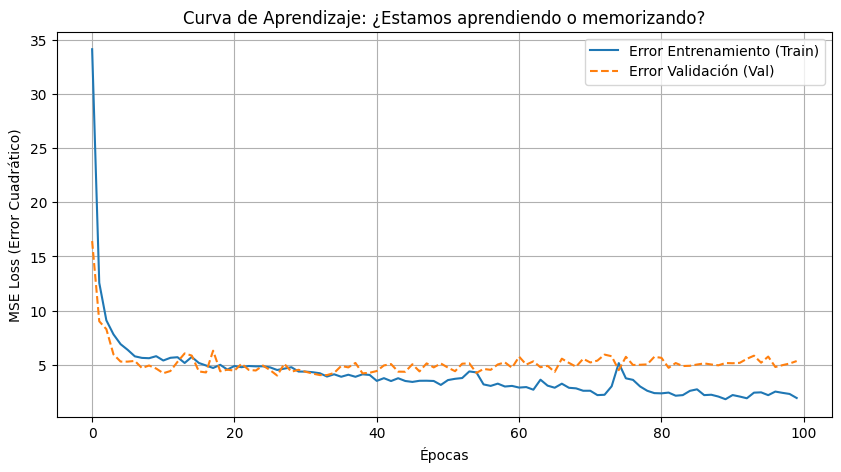

In [33]:
import matplotlib.pyplot as plt
import time

GRUmodel = COVIDGRU(input_dim=X.shape[2], hidden_dim=best_lstm_params['hidden_dim'], num_layers=best_lstm_params['num_layers'], output_dim=1, dropout=best_lstm_params['dropout'])
GRUmodel.to(device)

GRUcriterion = nn.MSELoss()
GRUoptimizer = torch.optim.Adam(GRUmodel.parameters(), lr=best_lstm_params['lr'])

# Configuración del entrenamiento
num_epochs = 100  # Número de veces que la red verá todos los datos
train_losses = []
val_losses = []

print(f"--- Iniciando entrenamiento en {device} ---")
start_time = time.time()

for epoch in range(num_epochs):
    # 1. FASE DE ENTRENAMIENTO
    GRUmodel.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover a GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # a) Reiniciar gradientes (siempre al principio)
        GRUoptimizer.zero_grad()

        # b) Predicción (Forward)
        y_pred = GRUmodel(X_batch)

        # c) Calcular error (Loss)
        loss = GRUcriterion(y_pred, y_batch)

        # d) Aprender (Backward & Step)
        loss.backward()   # Calcular gradientes
        GRUoptimizer.step()  # Actualizar pesos

        running_loss += loss.item()

    # Promedio de error en entrenamiento
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

   # 2. FASE DE VALIDACIÓN (DEV)
    GRUmodel.eval() # Pone el modelo en modo "examen" (desactiva Dropout)
    val_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            pred = GRUmodel(X_val)
            loss_t = GRUcriterion(pred, y_val)
            val_loss += loss_t.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular factor de escala (Rango de los datos originales)
    # Si escalaste solo la columna 'y', data_range_ es un array de 1 elemento.
    scale_factor = scaler.data_range_[0]

    # Convertir MSE escalado a RMSE Real (Personas)
    rmse_real_epoch = (avg_val_loss ** 0.5) * scale_factor

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss (MSE Scaled): {avg_val_loss:.5f} | Error Real Aprox: {rmse_real_epoch:.2f} personas")

print(f"\n--- Entrenamiento finalizado en {time.time() - start_time:.1f} segundos ---")

# --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Error Entrenamiento (Train)')
plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Error Cuadrático)')
plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
plt.legend()
plt.grid(True)
plt.show()


##Otro enfoque: GNNs

- Nodos: Las Zonas de Salud (Abetxuko, Casco Viejo, etc.).

- Aristas: ¿Quién es vecino de quién?

Problema: En el JSON no tenemos las coordenadas geográficas para saber qué zonas se tocan. Solución de "Matrícula": Vamos a inferir el grafo basándonos en la correlación. Si dos zonas suben y bajan de casos a la vez, asumiremos que están "conectadas" (hay flujo de gente entre ellas).

### PASO 1: Preparar los Datos (Formato Grafo)
Necesitamos una matriz de dimensiones (Días, Nodos, Features).

In [34]:
import pandas as pd
import numpy as np
import torch

# 1. Cargar datos de Zonas de Salud
# Asumimos que 'raw_data' tiene el JSON cargado como hicimos al principio
# Si no, cárgalo de nuevo:
# with open('covid19-byhealthzone.json', 'r', encoding='latin-1') as f:
#     raw_data = json.load(f)

data_list = []
for entry in raw_data['zonas_salud']['newPositivesByDateByHealthZone']:
    date = pd.to_datetime(entry['date'], errors='coerce')
    if pd.notnull(date):
        for item in entry['items']:
            zone_name = item['healthZone']['name'] # Extracting the 'name' from the dictionary
            cases = item.get('newPositiveCount', 0)
            data_list.append({'date': date, 'zone': zone_name, 'cases': cases})

df = pd.DataFrame(data_list)

# 2. Pivotar: Filas=Días, Columnas=Zonas
# Rellenamos nulos con 0
df_pivot = df.pivot_table(index='date', columns='zone', values='cases', fill_value=0)

# Normalizamos (MinMax)
scaler_gnn = MinMaxScaler()
data_scaled = scaler_gnn.fit_transform(df_pivot)

# Convertimos a Tensor (Días, Nodos, 1 Feature)
# X_graph shape: [T, N, 1]
X_graph = torch.tensor(data_scaled, dtype=torch.float32).unsqueeze(-1)

print(f"Dimensiones del Tensor Grafo: {X_graph.shape}")
# Ejemplo: (300 días, 150 zonas, 1 característica)


Dimensiones del Tensor Grafo: torch.Size([1133, 135, 1])


### PASO 2: Crear la Matriz de Adyacencia
La propagación de información depende de la matriz $A$. Como no tenemos mapa físico, creamos uno matemático.

In [35]:
# Calculamos correlación entre zonas (transpuesta porque corr trabaja por columnas)
correlation_matrix = df_pivot.corr().values

# Creamos la Adyacencia: Conectamos si la correlación > 0.7
# Esto significa: "Si en la zona A suben los casos, y en la B también, asumo que están conectadas"
adj_matrix = np.where(correlation_matrix > 0.7, 1, 0)

# Importante: Añadir self-loops (cada nodo se conecta consigo mismo)
np.fill_diagonal(adj_matrix, 1)

# Normalización de la matriz (Paso clave en GCN)
# D^(-1/2) * A * D^(-1/2)
degrees = np.sum(adj_matrix, axis=1)
D_inv_sqrt = np.power(degrees, -0.5)
D_inv_sqrt[np.isinf(D_inv_sqrt)] = 0.
D_mat_inv_sqrt = np.diag(D_inv_sqrt)

# A_hat es la matriz normalizada lista para la red neuronal
A_hat = D_mat_inv_sqrt @ adj_matrix @ D_mat_inv_sqrt
A_hat = torch.tensor(A_hat, dtype=torch.float32).to(device)

print("Matriz de Adyacencia construida y normalizada.")

Matriz de Adyacencia construida y normalizada.


### PASO 3: El Modelo GNN (Graph Convolutional Network)
Implementaremos la capa de Convolución de Grafos (GCN) manualmente, tal como se define matemáticamente:

$$H^{(l+1)} = \sigma(\hat{A} H^{(l)} W^{(l)})$$

In [36]:
import torch.nn as nn
import torch.nn.functional as F

class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features, bias=True)

    def forward(self, A_hat, X):
        # X shape: (Batch/Time, Nodos, In_Features)
        # A_hat shape: (Nodos, Nodos)

        # 1. Agregación de mensajes (Multiplicar por Adyacencia)
        # AX suma la información de los vecinos
        out = torch.matmul(A_hat, X)

        # 2. Transformación lineal (Multiplicar por Pesos W)
        out = self.linear(out)

        return out

class COVIDGNN(nn.Module):
    def __init__(self, num_nodes, in_features, hidden_dim, out_features, dropout=0.3):
        super(COVIDGNN, self).__init__()

        # Capas GCN
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, hidden_dim)

        # Capa final
        self.fc = nn.Linear(hidden_dim, out_features)

        # Dropout dinámico (ahora lo podemos cambiar en el grid search)
        self.dropout_layer = nn.Dropout(dropout)

    def forward(self, A_hat, x):
        # x: [Batch, Nodos, Features]
        x = self.gcn1(A_hat, x)
        x = F.relu(x)
        x = self.dropout_layer(x) # Usamos el dropout variable

        x = self.gcn2(A_hat, x)
        x = F.relu(x)

        out = self.fc(x)
        return out

### Búsqueda de hiperparámetros

In [37]:
import itertools

def grid_search_gnn(X_train, y_train, X_val, y_val, adj_matrix, device):
    print(f"\n Iniciando Grid Search para GNN...")

    # Rejilla adaptada a Grafos (suelen necesitar LR más alto)
    param_grid = {
        'lr': [0.01, 0.005],      # GNNs a veces convergen mejor con 0.01
        'hidden_dim': [32, 64],   # Pocos nodos -> pocas neuronas para no sobreajustar
        'dropout': [0.3, 0.5]     # Grafos necesitan bastante regularización
    }

    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

    best_loss = float('inf')
    best_params = {}

    # Mover datos fijos a GPU una sola vez para ganar velocidad
    X_tr_dev = X_train.to(device)
    y_tr_dev = y_train.to(device)
    X_val_dev = X_val.to(device)
    y_val_dev = y_val.to(device)
    adj_dev = adj_matrix.to(device) # La matriz A siempre está en GPU

    for i, params in enumerate(combinations):
        lr = params['lr']
        hd = params['hidden_dim']
        dr = params['dropout']

        print(f"   [{i+1}/{len(combinations)}] GNN | LR={lr}, Hidden={hd}, Drop={dr} ...", end="")

        # 1. Instanciar
        # num_nodes lo sacamos de la forma de X_train (Batch, Nodos, Features)
        n_nodes = X_train.shape[1]
        model = COVIDGNN(num_nodes=n_nodes, in_features=1, hidden_dim=hd,
                          out_features=1, dropout=dr).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = torch.nn.MSELoss()

        # 2. Entrenar (Bucle manual sin DataLoader, pasamos todo el tensor)
        model.train()
        for epoch in range(10): # 10 épocas para grafos (necesitan un poco más para arrancar)
            optimizer.zero_grad()
            out = model(adj_dev, X_tr_dev)
            loss = criterion(out, y_tr_dev)
            loss.backward()
            optimizer.step()

        # 3. Validar
        model.eval()
        with torch.no_grad():
            out_v = model(adj_dev, X_val_dev)
            val_loss = criterion(out_v, y_val_dev).item()

        print(f" -> Val Loss: {val_loss:.5f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_params = params

    print(f"GANADOR GNN: {best_params}")
    return best_params

# ==========================================
# PREPARACIÓN DE DATOS TRAIN/TEST (GNN)
# ==========================================

# X_graph tiene forma: [Total_Días, Nodos, 1]

# 1. Definir Input (hoy) y Target (mañana)
# X_all: Todos los días MENOS el último (porque el último no tiene "mañana" con qué comparar)
X_all = X_graph[:-1]

# y_all: Todos los días MENOS el primero (porque el primero no es "mañana" de nadie en nuestros datos)
y_all = X_graph[1:]

# 2. Definir el punto de corte cronológico (80% train, 20% test)
train_size = int(len(X_all) * 0.7)
dev_size = int(len(X_all) * 0.15)

# 3. Crear las 4 variables que necesitas
# --- ENTRENAMIENTO ---
x_tr = X_all[:train_size]
y_tr = y_all[:train_size]

# --- VALIDACIÓN ---
x_dev = X_all[train_size:train_size+dev_size]
y_dev = y_all[train_size:train_size+dev_size]

x_test = X_all[train_size+dev_size:]
y_test = y_all[train_size+dev_size:]

print(f"--- Dimensiones GNN ---")
print(f"X_tr shape: {x_tr.shape}") # (Días_Train, Nodos, 1)
print(f"y_tr shape: {y_tr.shape}")
print(f"X_te shape: {x_dev.shape}")
print(f"y_te shape: {y_dev.shape}")

best_gnn_params = grid_search_gnn(x_tr, y_tr, x_dev, y_dev, A_hat, device)

--- Dimensiones GNN ---
X_tr shape: torch.Size([792, 135, 1])
y_tr shape: torch.Size([792, 135, 1])
X_te shape: torch.Size([169, 135, 1])
y_te shape: torch.Size([169, 135, 1])

 Iniciando Grid Search para GNN...
   [1/8] GNN | LR=0.01, Hidden=32, Drop=0.3 ... -> Val Loss: 0.00053
   [2/8] GNN | LR=0.01, Hidden=32, Drop=0.5 ... -> Val Loss: 0.00048
   [3/8] GNN | LR=0.01, Hidden=64, Drop=0.3 ... -> Val Loss: 0.00504
   [4/8] GNN | LR=0.01, Hidden=64, Drop=0.5 ... -> Val Loss: 0.00074
   [5/8] GNN | LR=0.005, Hidden=32, Drop=0.3 ... -> Val Loss: 0.00037
   [6/8] GNN | LR=0.005, Hidden=32, Drop=0.5 ... -> Val Loss: 0.00041
   [7/8] GNN | LR=0.005, Hidden=64, Drop=0.3 ... -> Val Loss: 0.00565
   [8/8] GNN | LR=0.005, Hidden=64, Drop=0.5 ... -> Val Loss: 0.00093
GANADOR GNN: {'lr': 0.005, 'hidden_dim': 32, 'dropout': 0.3}


### PASO 4: Entrenamiento (Adaptado a Grafos)
A diferencia del LSTM, aquí le pasamos "fotos" completas de Euskadi (todos los nodos a la vez).

--- Iniciando entrenamiento GNN (Graph Neural Network) ---
Epoch 20/1000 | Train Loss: 0.00685 | Val Loss: 0.00225
Epoch 40/1000 | Train Loss: 0.00306 | Val Loss: 0.00030
Epoch 60/1000 | Train Loss: 0.00286 | Val Loss: 0.00033
Epoch 80/1000 | Train Loss: 0.00280 | Val Loss: 0.00028
Epoch 100/1000 | Train Loss: 0.00277 | Val Loss: 0.00029
Epoch 120/1000 | Train Loss: 0.00277 | Val Loss: 0.00030
Epoch 140/1000 | Train Loss: 0.00275 | Val Loss: 0.00029
Epoch 160/1000 | Train Loss: 0.00276 | Val Loss: 0.00030
Epoch 180/1000 | Train Loss: 0.00279 | Val Loss: 0.00029
Epoch 200/1000 | Train Loss: 0.00277 | Val Loss: 0.00030
Epoch 220/1000 | Train Loss: 0.00277 | Val Loss: 0.00030
Epoch 240/1000 | Train Loss: 0.00279 | Val Loss: 0.00030
Epoch 260/1000 | Train Loss: 0.00275 | Val Loss: 0.00030
Epoch 280/1000 | Train Loss: 0.00275 | Val Loss: 0.00030
Epoch 300/1000 | Train Loss: 0.00275 | Val Loss: 0.00030
Epoch 320/1000 | Train Loss: 0.00274 | Val Loss: 0.00031
Epoch 340/1000 | Train Loss: 0.00

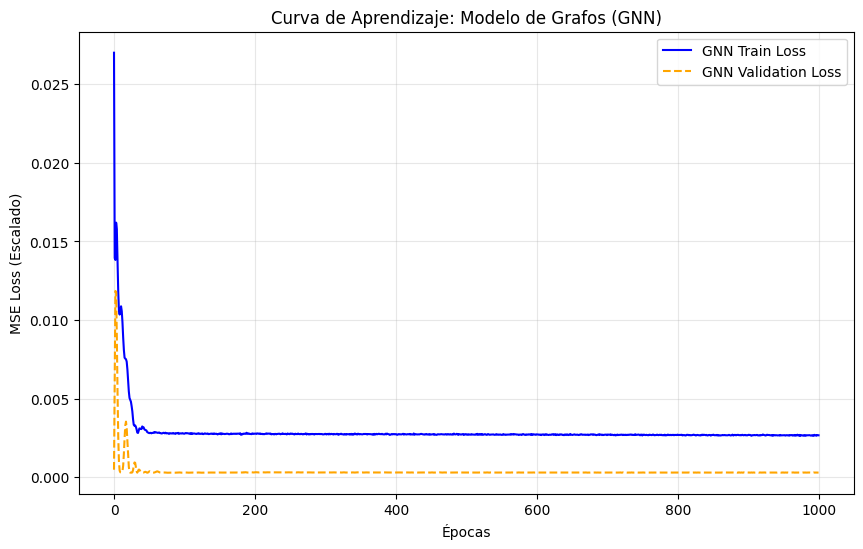


Resultados GNN en el Mundo Real:
MAE (Error Medio por Zona y Día): 1.41 casos


In [38]:
import matplotlib.pyplot as plt

# 1. Configuración
epochs = 1000  # Las GNN a veces necesitan más épocas para estabilizarse
modelGNN = COVIDGNN(num_nodes=x_tr.shape[1], in_features=1,
                      hidden_dim=best_gnn_params['hidden_dim'],
                      out_features=1,
                      dropout=best_gnn_params['dropout']).to(device)

optimizerGNN = torch.optim.Adam(modelGNN.parameters(), lr=best_gnn_params['lr'])
criterionGNN = nn.MSELoss()

# Listas para guardar historial
train_losses = []
val_losses = []

print("--- Iniciando entrenamiento GNN (Graph Neural Network) ---")

for epoch in range(1, epochs + 1):
    # --- FASE ENTRENAMIENTO ---
    modelGNN.train()
    optimizerGNN.zero_grad()

    # 1. Pasada hacia adelante con datos de TRAIN
    # Nota: Pasamos la matriz de adyacencia (A_hat) y los datos de entrenamiento
    X_batch = x_tr.to(device)
    y_batch = y_tr.to(device)

    out = modelGNN(A_hat, X_batch)
    loss = criterionGNN(out, y_batch)

    # 2. Backprop
    loss.backward()
    optimizerGNN.step()

    # Guardamos error train
    train_losses.append(loss.item())

    # --- FASE VALIDACIÓN ---
    modelGNN.eval()
    with torch.no_grad():
        # Pasada hacia adelante con datos de TEST/VALIDATION
        X_val_batch = x_dev.to(device)
        y_val_batch = y_dev.to(device)

        out_val = modelGNN(A_hat, X_val_batch)
        val_loss = criterionGNN(out_val, y_val_batch)

        # Guardamos error val
        val_losses.append(val_loss.item())

    # Print log cada 20 épocas
    if epoch % 20 == 0:
        print(f"Epoch {epoch}/{epochs} | Train Loss: {loss.item():.5f} | Val Loss: {val_loss.item():.5f}")

print("Entrenamiento GNN finalizado.")

# --- DIBUJAR CURVAS ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='GNN Train Loss', color='blue')
plt.plot(val_losses, label='GNN Validation Loss', color='orange', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Escalado)')
plt.title('Curva de Aprendizaje: Modelo de Grafos (GNN)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- CÁLCULO DE ERROR REAL (DESESCALADO) ---
# Para comparar peras con peras con el LSTM
import numpy as np

# Get original dimensions for validation set
num_val_steps = x_dev.shape[0] # number of days in validation set
num_zones = x_dev.shape[1]   # number of health zones

# Reshape predictions and targets to (num_val_steps, num_zones)
# This removes the last singleton dimension and matches the shape scaler_gnn was fitted on (days, zones)
preds_val_reshaped = out_val.cpu().numpy().squeeze() # Shape: (num_val_steps, num_zones)
targets_val_reshaped = y_val_batch.cpu().numpy().squeeze() # Shape: (num_val_steps, num_zones)

# Now apply inverse_transform
preds_real_gnn = scaler_gnn.inverse_transform(preds_val_reshaped)
targets_real_gnn = scaler_gnn.inverse_transform(targets_val_reshaped)

# Calculate MAE
mae_gnn = np.mean(np.abs(targets_real_gnn - preds_real_gnn))
print(f"\nResultados GNN en el Mundo Real:")
print(f"MAE (Error Medio por Zona y Día): {mae_gnn:.2f} casos")

##Uso del mejor modelo sobre el conjunto de test

El mejor modelo que hemos encontrado es LSTM con los datos en orden secuencial, por lo que vamos a probarlo sobre el conjunto de test.

In [45]:
# ==========================================
# 4. PREPARACIÓN PARA PYTORCH (Scaler solo con train)
# ==========================================

# --- 1. División cronológica para definir train/val/test ---
prop_train = 0.70
prop_val   = 0.15
n_samples  = len(df_master)
train_idx  = int(n_samples * prop_train)
val_idx    = int(n_samples * (prop_train + prop_val))

# --- 2. Escalado (MinMax) solo usando train ---
scaler = MinMaxScaler()
scaler.fit(df_master[features_cols][:train_idx])  # Ajuste solo con train
data_scaled = scaler.transform(df_master[features_cols])  # Transformamos todo

# --- 3. Crear secuencias (ventana deslizante) ---
WINDOW_SIZE = 7
target_col_idx = features_cols.index('target_muertes')

X_list, y_list = [], []
for i in range(len(data_scaled) - WINDOW_SIZE):
    X_list.append(data_scaled[i : i + WINDOW_SIZE])                # Ventana de 7 días
    y_list.append(data_scaled[i + WINDOW_SIZE, target_col_idx])   # Muertes día siguiente

X = np.array(X_list)
y = np.array(y_list)

# --- 4. Tensores ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.from_numpy(X).float().to(device)
y_tensor = torch.from_numpy(y).float().to(device)

# --- 5. División cronológica en train/val/test usando los índices calculados ---
train_dataset = TensorDataset(X_tensor[:train_idx], y_tensor[:train_idx])
val_dataset   = TensorDataset(X_tensor[train_idx:val_idx], y_tensor[train_idx:val_idx])
test_dataset  = TensorDataset(X_tensor[val_idx:], y_tensor[val_idx:])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\n--- Datos Listos para Entrenamiento ---")
print(f"X Train shape: {X_tensor[:train_idx].shape}")
print(f"X Val shape:   {X_tensor[train_idx:val_idx].shape}")
print(f"X Test shape:  {X_tensor[val_idx:].shape}")
print(f"Dispositivo: {device}")



--- Datos Listos para Entrenamiento ---
X Train shape: torch.Size([1706, 7, 35])
X Val shape:   torch.Size([366, 7, 35])
X Test shape:  torch.Size([359, 7, 35])
Dispositivo: cpu


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


--- Iniciando entrenamiento en cpu ---
Época [10/100] | Train Loss: 0.01085 | Val Loss (MSE Scaled): 0.01177 | Error Real Aprox: 5.53 personas
Época [20/100] | Train Loss: 0.00902 | Val Loss (MSE Scaled): 0.00737 | Error Real Aprox: 4.38 personas
Época [30/100] | Train Loss: 0.00538 | Val Loss (MSE Scaled): 0.00353 | Error Real Aprox: 3.03 personas
Época [40/100] | Train Loss: 0.00316 | Val Loss (MSE Scaled): 0.00133 | Error Real Aprox: 1.86 personas
Época [50/100] | Train Loss: 0.00240 | Val Loss (MSE Scaled): 0.00182 | Error Real Aprox: 2.17 personas
Época [60/100] | Train Loss: 0.00316 | Val Loss (MSE Scaled): 0.00351 | Error Real Aprox: 3.02 personas
Época [70/100] | Train Loss: 0.00255 | Val Loss (MSE Scaled): 0.00298 | Error Real Aprox: 2.79 personas
Época [80/100] | Train Loss: 0.00277 | Val Loss (MSE Scaled): 0.00261 | Error Real Aprox: 2.61 personas
Época [90/100] | Train Loss: 0.00294 | Val Loss (MSE Scaled): 0.00292 | Error Real Aprox: 2.76 personas
Época [100/100] | Train L

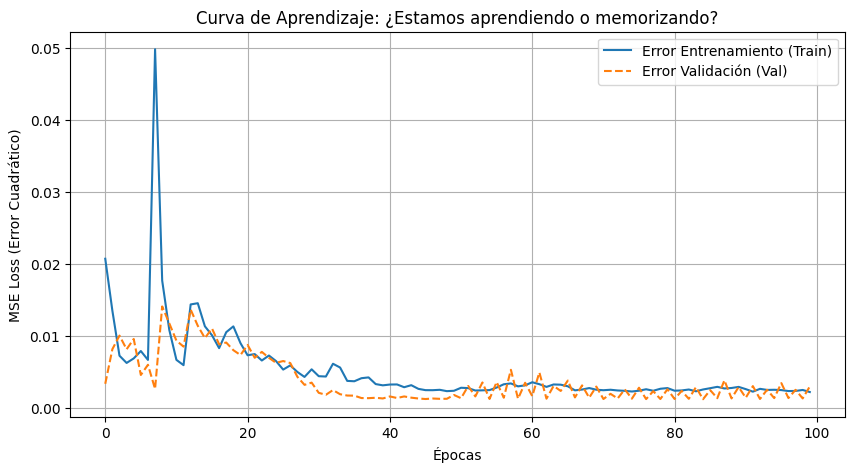

In [46]:
import matplotlib.pyplot as plt
import time

LSTMmodel = COVIDLSTM(input_dim=X.shape[2], hidden_dim=best_lstm_params['hidden_dim'], num_layers=best_lstm_params['num_layers'], output_dim=1, dropout=best_lstm_params['dropout'])
LSTMmodel.to(device)

LSTMcriterion = nn.MSELoss()
LSTMoptimizer = torch.optim.Adam(LSTMmodel.parameters(), lr=best_lstm_params['lr'])

# Configuración del entrenamiento
num_epochs = 100  # Número de veces que la red verá todos los datos
train_losses = []
val_losses = []

print(f"--- Iniciando entrenamiento en {device} ---")
start_time = time.time()

for epoch in range(num_epochs):
    # 1. FASE DE ENTRENAMIENTO
    LSTMmodel.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover a GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # a) Reiniciar gradientes (siempre al principio)
        LSTMoptimizer.zero_grad()

        # b) Predicción (Forward)
        y_pred = LSTMmodel(X_batch)

        # c) Calcular error (Loss)
        loss = LSTMcriterion(y_pred, y_batch)

        # d) Aprender (Backward & Step)
        loss.backward()   # Calcular gradientes
        LSTMoptimizer.step()  # Actualizar pesos

        running_loss += loss.item()

    # Promedio de error en entrenamiento
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

   # 2. FASE DE VALIDACIÓN (DEV)
    LSTMmodel.eval() # Pone el modelo en modo "examen" (desactiva Dropout)
    val_loss = 0.0
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            pred = LSTMmodel(X_val)
            loss_t = LSTMcriterion(pred, y_val)
            val_loss += loss_t.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular factor de escala (Rango de los datos originales)
    # Si escalaste solo la columna 'y', data_range_ es un array de 1 elemento.
    scale_factor = scaler.data_range_[0]

    # Convertir MSE escalado a RMSE Real (Personas)
    rmse_real_epoch = (avg_val_loss ** 0.5) * scale_factor

    # Imprimir progreso cada 10 épocas
    if (epoch + 1) % 10 == 0:
        print(f"Época [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss (MSE Scaled): {avg_val_loss:.5f} | Error Real Aprox: {rmse_real_epoch:.2f} personas")

print(f"\n--- Entrenamiento finalizado en {time.time() - start_time:.1f} segundos ---")

# --- 3. VISUALIZACIÓN DE LA PÉRDIDA ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Error Entrenamiento (Train)')
plt.plot(val_losses, label='Error Validación (Val)', linestyle='--')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss (Error Cuadrático)')
plt.title('Curva de Aprendizaje: ¿Estamos aprendiendo o memorizando?')
plt.legend()
plt.grid(True)
plt.show()




--- Iniciando Evaluación en Test ---

RESULTADOS FINALES (Escala Real):
MAE:  2.0963 (Error medio absoluto)
RMSE: 2.8018 (Raíz del error cuadrático medio)


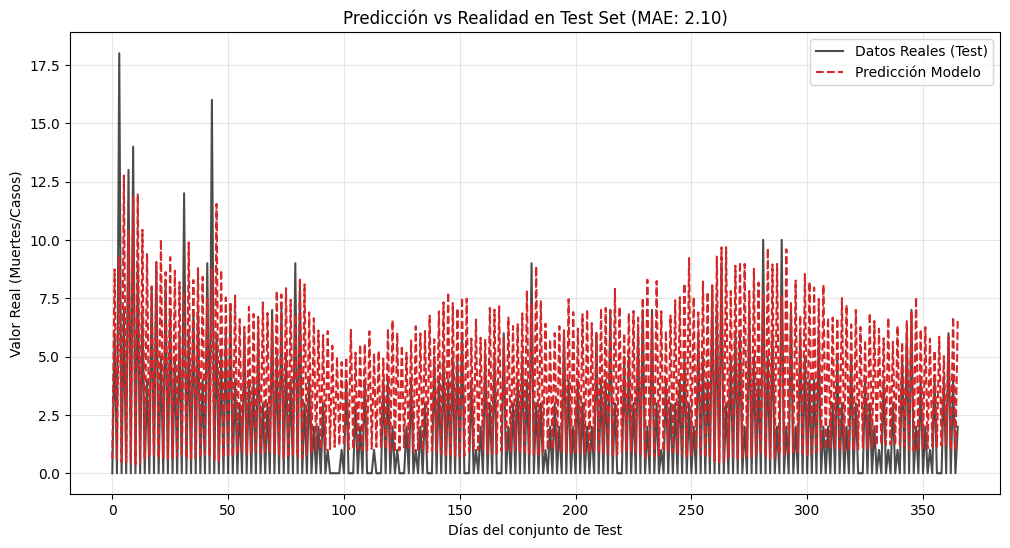

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluar_modelo_final(model, test_loader, scaler, device, target_col_idx=0):
    """
    Evalúa el modelo en el set de test, desescala los resultados y grafica la comparación.

    Args:
        model: El modelo entrenado (ej: lstm_final, gru_final).
        test_loader: DataLoader con los datos de test.
        scaler: El objeto MinMaxScaler usado originalmente.
        device: 'cuda' o 'cpu'.
        target_col_idx: Índice de la columna objetivo en el dataset original (normalmente 0).
    """
    model.eval()
    preds = []
    actuals = []

    print("--- Iniciando Evaluación en Test ---")

    # 1. Generar predicciones
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            y = y.to(device)

            # Forward pass
            output = model(X)

            # Soporte para modelos que devuelven tuplas (como Attention)
            if isinstance(output, tuple):
                output = output[0]

            # Guardamos en listas (CPU)
            preds.extend(output.cpu().numpy().flatten())
            actuals.extend(y.cpu().numpy().flatten())

    # 2. Convertir a arrays columna
    pred_arr = np.array(preds).reshape(-1, 1)
    act_arr = np.array(actuals).reshape(-1, 1)

    # 3. DESESCALADO (Truco de la matriz dummy)
    # El scaler espera (N, 35) pero tenemos (N, 1). Rellenamos el resto con ceros.
    n_features = scaler.n_features_in_

    # Matrices vacías con la forma correcta
    dummy_pred = np.zeros((len(pred_arr), n_features))
    dummy_act = np.zeros((len(act_arr), n_features))

    # Rellenamos solo la columna del target
    dummy_pred[:, target_col_idx] = pred_arr.flatten()
    dummy_act[:, target_col_idx] = act_arr.flatten()

    # Invertimos la transformación
    inv_pred = scaler.inverse_transform(dummy_pred)[:, target_col_idx]
    inv_act = scaler.inverse_transform(dummy_act)[:, target_col_idx]

    # 4. Cálculo de Métricas Reales
    mae = mean_absolute_error(inv_act, inv_pred)
    rmse = np.sqrt(mean_squared_error(inv_act, inv_pred))

    print(f"\nRESULTADOS FINALES (Escala Real):")
    print(f"MAE:  {mae:.4f} (Error medio absoluto)")
    print(f"RMSE: {rmse:.4f} (Raíz del error cuadrático medio)")

    # 5. GRAFICAR
    plt.figure(figsize=(12, 6))
    plt.plot(inv_act, label='Datos Reales (Test)', color='black', alpha=0.7)
    plt.plot(inv_pred, label='Predicción Modelo', color='#d62728', linestyle='--')

    plt.title(f'Predicción vs Realidad en Test Set (MAE: {mae:.2f})')
    plt.xlabel('Días del conjunto de Test')
    plt.ylabel('Valor Real (Muertes/Casos)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return inv_pred, inv_act



y_p, y_t = evaluar_modelo_final(LSTMmodel, val_loader, scaler, device, target_col_idx=0)
